# RECS 2020 Household Electricity Regression Workflow

End-to-end regression of U.S. household annual electricity consumption (KWH) using the 2020 EIA RECS microdata.

**Workflow:** Raw inspection → Target selection → Column set → Cleaning & engineering → EDA → Feature selection → VIF review → OLS (baseline + pruned) → Regularised models → Engineered-feature extension → Model comparison

**Notes:** Standard train/test split (cross-sectional data). Survey weights retained as metadata; fitting is unweighted. Every model reports train/test R², adj-R², RMSE, MAE, MAPE on both log and KWH scales.

## 0. Imports & Configuration

In [1]:
import os, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNetCV, LassoCV, LinearRegression, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from statsmodels.stats.diagnostic import het_breuschpagan, kstest_normal
from statsmodels.stats.outliers_influence import variance_inflation_factor

from pathlib import Path
output_dir = Path('output_plots')
output_dir.mkdir(exist_ok=True)

warnings.filterwarnings('ignore')
os.environ.setdefault('MPLCONFIGDIR', '/tmp/mpl')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)
sns.set_theme(style='whitegrid', context='notebook', palette='muted')

# Attempt to mount Google Drive if in Colab
try:
    from google.colab import drive
    if not Path('/content/drive').exists():
        drive.mount('/content/drive')
except ImportError:
    drive = None

CONFIG = {
    'test_size': 0.20,
    'random_state': 42,
    'diagnostic_plot_sample': 5000,
    'run_hist_gradient_boosting': True,
}

possible_paths = [
    Path('./recs_dataset.csv'),                                   # Root folder
    Path('/content/drive/MyDrive/electricity/recs_dataset.csv'),  # Mounted Drive
]

DATA_PATH = None
for path in possible_paths:
    if path.exists():
        DATA_PATH = path
        break

# Raise a clear error if the file is missing from all locations
if DATA_PATH is None:
    raise FileNotFoundError("Could not find the data file in the mounted drive or the root folder.")

print(f'Using data file: {DATA_PATH}')

Using data file: recs_dataset.csv


## 1. Raw File Inspection

Audit the file as delivered: shape, dtypes, missing values, weight columns.

In [2]:
raw_df = pd.read_csv(DATA_PATH)
print(f'Shape: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns')

missing = (
    raw_df.isna().sum().rename('missing_count').reset_index()
    .rename(columns={'index': 'column'})
    .assign(missing_pct=lambda d: (d['missing_count'] / len(raw_df) * 100).round(2))
    .query('missing_count > 0')
    .sort_values('missing_count', ascending=False)
)
print(f'Columns with missing values: {len(missing)}')
display(missing.head(20))

print(f'Duplicate rows: {raw_df.duplicated().sum()}')

weight_cols = [c for c in raw_df.columns if 'WEIGHT' in c.upper() or c.startswith('NWEIGHT')]
print(f'Weight columns: {weight_cols}')
display(raw_df[weight_cols].describe().round(1))

Shape: 18,496 rows x 799 columns
Columns with missing values: 10


,column,missing_count,missing_pct
240,MEDICALDEV,210,1.14
794,EVCHRGDLR,75,0.41
795,EVCHRGHWY,72,0.39
793,EVCHRGMUNI,72,0.39
792,EVCHRGBUS,68,0.37
796,EVCHRGOTH,64,0.35
791,EVCHRGWKS,62,0.34
789,EVCHRGHOME,11,0.06
797,EVHOMEAMT,10,0.05
798,EVCHRGTYPE,9,0.05


Duplicate rows: 0
Weight columns: ['NWEIGHT', 'NWEIGHT1', 'NWEIGHT2', 'NWEIGHT3', 'NWEIGHT4', 'NWEIGHT5', 'NWEIGHT6', 'NWEIGHT7', 'NWEIGHT8', 'NWEIGHT9', 'NWEIGHT10', 'NWEIGHT11', 'NWEIGHT12', 'NWEIGHT13', 'NWEIGHT14', 'NWEIGHT15', 'NWEIGHT16', 'NWEIGHT17', 'NWEIGHT18', 'NWEIGHT19', 'NWEIGHT20', 'NWEIGHT21', 'NWEIGHT22', 'NWEIGHT23', 'NWEIGHT24', 'NWEIGHT25', 'NWEIGHT26', 'NWEIGHT27', 'NWEIGHT28', 'NWEIGHT29', 'NWEIGHT30', 'NWEIGHT31', 'NWEIGHT32', 'NWEIGHT33', 'NWEIGHT34', 'NWEIGHT35', 'NWEIGHT36', 'NWEIGHT37', 'NWEIGHT38', 'NWEIGHT39', 'NWEIGHT40', 'NWEIGHT41', 'NWEIGHT42', 'NWEIGHT43', 'NWEIGHT44', 'NWEIGHT45', 'NWEIGHT46', 'NWEIGHT47', 'NWEIGHT48', 'NWEIGHT49', 'NWEIGHT50', 'NWEIGHT51', 'NWEIGHT52', 'NWEIGHT53', 'NWEIGHT54', 'NWEIGHT55', 'NWEIGHT56', 'NWEIGHT57', 'NWEIGHT58', 'NWEIGHT59', 'NWEIGHT60']


,NWEIGHT,NWEIGHT1,NWEIGHT2,NWEIGHT3,NWEIGHT4,NWEIGHT5,NWEIGHT6,NWEIGHT7,NWEIGHT8,NWEIGHT9,NWEIGHT10,NWEIGHT11,NWEIGHT12,NWEIGHT13,NWEIGHT14,NWEIGHT15,NWEIGHT16,NWEIGHT17,NWEIGHT18,NWEIGHT19,NWEIGHT20,NWEIGHT21,NWEIGHT22,NWEIGHT23,NWEIGHT24,NWEIGHT25,NWEIGHT26,NWEIGHT27,NWEIGHT28,NWEIGHT29,NWEIGHT30,NWEIGHT31,NWEIGHT32,NWEIGHT33,NWEIGHT34,NWEIGHT35,NWEIGHT36,NWEIGHT37,NWEIGHT38,NWEIGHT39,NWEIGHT40,NWEIGHT41,NWEIGHT42,NWEIGHT43,NWEIGHT44,NWEIGHT45,NWEIGHT46,NWEIGHT47,NWEIGHT48,NWEIGHT49,NWEIGHT50,NWEIGHT51,NWEIGHT52,NWEIGHT53,NWEIGHT54,NWEIGHT55,NWEIGHT56,NWEIGHT57,NWEIGHT58,NWEIGHT59,NWEIGHT60
count,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0,18496.0
mean,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7,6678.7
std,3836.8,3969.6,3958.2,3961.6,3960.8,3973.4,3955.9,3971.8,3967.6,3970.6,3965.3,3962.4,3968.0,3964.3,3962.6,3966.5,3965.2,3977.9,3967.9,3960.5,3970.6,3974.2,3963.8,3979.0,3969.3,3969.2,3960.8,3982.3,3962.6,3965.5,3963.0,3973.4,3956.6,3963.6,3964.5,3961.8,3963.3,3973.5,3971.3,3972.2,3970.0,3963.2,3959.3,3965.6,3961.0,3971.4,3957.1,3972.3,3962.2,3964.7,3971.3,3955.6,3965.9,3962.8,3968.8,3968.7,3961.8,3969.3,3959.9,3956.4,3963.7
min,437.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,4018.7,3950.3,3950.7,3954.0,3953.1,3956.6,3965.6,3943.7,3955.9,3946.7,3960.7,3949.6,3947.1,3967.1,3961.6,3958.4,3957.8,3957.8,3937.3,3946.7,3942.6,3960.5,3964.5,3942.8,3946.0,3951.8,3965.5,3942.5,3956.0,3970.3,3956.0,3943.5,3954.4,3963.6,3950.1,3967.3,3947.9,3955.0,3954.1,3940.2,3959.2,3974.6,3949.2,3946.8,3955.8,3952.3,3966.3,3937.7,3952.6,3947.1,3948.3,3958.4,3937.6,3959.5,3954.2,3945.0,3956.6,3942.5,3961.8,3965.1,3952.7
50%,6119.4,6136.2,6150.7,6150.6,6153.0,6133.6,6147.2,6134.7,6150.5,6139.0,6163.2,6140.5,6160.0,6142.0,6154.2,6145.2,6132.7,6126.0,6155.4,6153.1,6138.5,6134.9,6149.0,6148.4,6135.6,6149.9,6136.4,6125.1,6149.3,6146.2,6148.9,6143.6,6159.1,6147.6,6138.5,6141.3,6149.4,6133.4,6138.8,6147.3,6144.1,6152.8,6137.3,6157.2,6147.8,6148.5,6152.0,6149.7,6138.5,6146.1,6159.4,6150.1,6153.8,6156.1,6151.3,6143.1,6152.7,6138.4,6137.3,6143.9,6140.0
75%,8890.0,8976.4,8979.0,8994.0,8998.3,8986.9,8983.8,8998.1,8988.4,8973.9,8993.5,8991.5,8988.1,8977.1,8980.7,8996.5,8979.3,8977.5,8993.3,8979.4,8992.2,8956.2,8987.6,8980.5,8977.8,8971.7,8979.6,8995.8,8988.5,8978.6,8991.0,8994.2,8981.7,8993.1,8985.0,8989.8,8979.2,8974.6,8973.8,8990.8,8979.8,8982.4,8987.9,9004.6,8985.8,8991.9,8958.9,8991.1,8990.8,8990.4,8995.4,8992.2,9011.7,8979.0,8972.5,8976.5,8994.6,9003.7,8985.8,8977.3,8982.5
max,29279.1,30015.5,29421.7,29431.4,29493.5,30039.3,29419.2,29586.5,29498.7,29844.7,29634.6,29681.4,29848.6,29842.6,30184.4,29969.9,29824.7,30606.1,29689.2,29336.1,30274.2,29766.5,29791.4,30126.3,29946.3,30445.2,29893.3,30029.7,29599.5,30136.0,29895.0,29604.3,29310.0,29408.1,29563.8,30437.1,27896.2,30596.1,30129.9,29261.7,30344.3,29593.8,29938.3,29878.1,29896.1,29729.0,29102.7,30069.6,29343.3,29590.4,30026.6,29246.6,29445.5,30131.5,29439.3,29216.0,29202.9,29818.7,29817.8,29606.4,29818.2


## 2. Target Selection

Compare candidate targets; select `log1p(KWH)` for modelling.

,candidate,meaning,skew
0,KWH,Annual kWh — direct outcome,1.826245
1,log1p(KWH),Log-transformed kWh — modelling target,-0.443721
2,DOLLAREL,Annual spend (outcome-adjacent),2.130665
3,TOTALBTU,Total site energy (multi-fuel leakage),2.718143


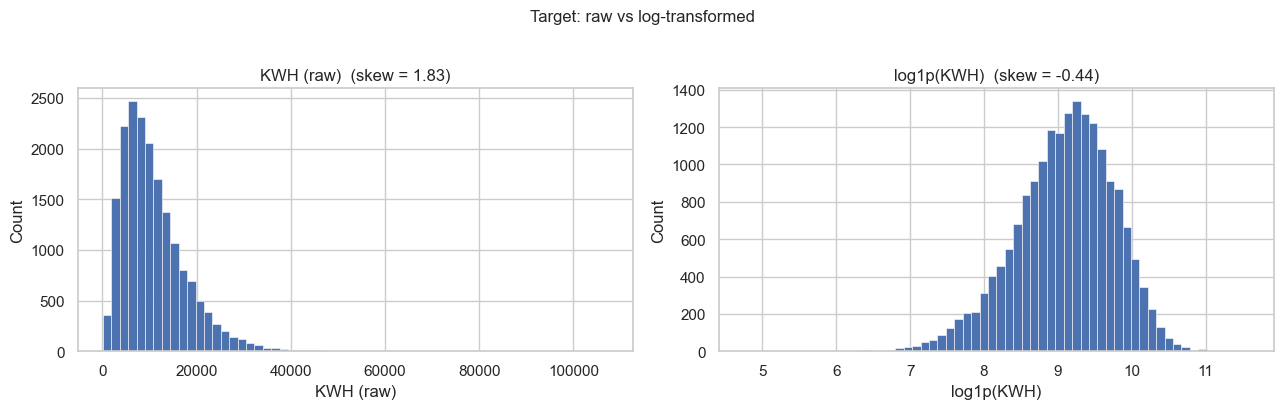

Selected target: log1p(KWH) -- reduces right skew, stabilises variance for OLS.


In [3]:
cands = pd.DataFrame([
    {'candidate': 'KWH',        'meaning': 'Annual kWh — direct outcome',          'skew': raw_df['KWH'].skew()},
    {'candidate': 'log1p(KWH)', 'meaning': 'Log-transformed kWh — modelling target','skew': np.log1p(raw_df['KWH']).skew()},
    {'candidate': 'DOLLAREL',   'meaning': 'Annual spend (outcome-adjacent)',        'skew': raw_df['DOLLAREL'].skew()},
    {'candidate': 'TOTALBTU',   'meaning': 'Total site energy (multi-fuel leakage)', 'skew': raw_df['TOTALBTU'].skew()},
])
display(cands)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (vals, label) in zip(axes, [
    (raw_df['KWH'],           'KWH (raw)'),
    (np.log1p(raw_df['KWH']), 'log1p(KWH)'),
]):
    vals = vals.dropna()
    ax.hist(vals, bins=60, color='#4C72B0', edgecolor='white', linewidth=0.4)
    ax.set_title(f'{label}  (skew = {vals.skew():.2f})')
    ax.set_xlabel(label); ax.set_ylabel('Count')
plt.suptitle('Target: raw vs log-transformed', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(output_dir / 'raw vs log-transform.png', dpi=600, bbox_inches='tight')
plt.show()

print('Selected target: log1p(KWH) -- reduces right skew, stabilises variance for OLS.')

## 3. Focused Column Set & Data Dictionary

Rather than cleaning all ~800 columns, we keep a focused set that supports a defensible household electricity regression. Leakage-prone outcome-adjacent fields (spend, total BTU) are excluded explicitly.

In [4]:
COLUMN_GROUPS = {
    'identifiers':          {'DOEID': 'household_id', 'NWEIGHT': 'final_weight',
                             'REGIONC': 'census_region', 'state_name': 'state_name'},
    'climate_geography':    {'BA_climate': 'ba_climate', 'UATYP10': 'urbanicity_code',
                             'HDD30YR_PUB': 'heating_degree_days_30yr',
                             'CDD30YR_PUB': 'cooling_degree_days_30yr'},
    'dwelling_structure':   {'TYPEHUQ': 'housing_unit_type_code', 'KOWNRENT': 'tenure_code',
                             'PRKGPLC1': 'attached_garage_code', 'STORIES': 'stories_code'},
    'size_vintage':         {'YEARMADERANGE': 'vintage_band_code', 'BEDROOMS': 'bedrooms',
                             'NCOMBATH': 'full_bathrooms', 'NHAFBATH': 'half_bathrooms',
                             'TOTROOMS': 'total_rooms', 'SQFTEST': 'reported_sqft',
                             'TOTSQFT_EN': 'conditioned_sqft', 'TOTHSQFT': 'heated_sqft',
                             'TOTCSQFT': 'cooled_sqft'},
    'equipment_systems':    {'AIRCOND': 'has_air_conditioning', 'HEATHOME': 'heats_home',
                             'CWASHER': 'has_clothes_washer', 'DRYER': 'has_dryer',
                             'DISHWASH': 'has_dishwasher', 'NUMFRIG': 'num_refrigerators',
                             'NUMFREEZ': 'num_freezers', 'NUMDLHPAC': 'num_ductless_ac_units',
                             'NUMWWAC': 'num_window_wall_ac_units',
                             'NUMPORTAC': 'num_portable_ac_units',
                             'NUMFLOORFAN': 'num_floor_fans', 'USECFAN': 'uses_ceiling_fan',
                             'SWIMPOOL': 'has_pool', 'WINECHILL': 'has_wine_chiller'},
    'household_behavior':   {'RCOOKUSE': 'cooktop_use_per_week', 'ROVENUSE': 'oven_use_per_week',
                             'DWASHUSE': 'dishwasher_use_per_week',
                             'WASHLOAD': 'washer_use_per_week', 'DRYRUSE': 'dryer_use_per_week',
                             'TEMPHOME': 'winter_temp_home_day', 'TEMPGONE': 'winter_temp_away',
                             'TEMPNITE': 'winter_temp_night',
                             'TEMPHOMEAC': 'summer_temp_home_day',
                             'TEMPGONEAC': 'summer_temp_away', 'TEMPNITEAC': 'summer_temp_night',
                             'LGTIN4TO8': 'lights_4_to_8_hours',
                             'LGTINMORE8': 'lights_over_8_hours',
                             'LGTOUTNITE': 'outdoor_lights_overnight',
                             'ATHOME': 'weekday_time_at_home_code'},
    'electronics':          {'TVCOLOR': 'num_tvs', 'CABLESAT': 'num_cable_boxes_no_dvr',
                             'COMBODVR': 'num_cable_boxes_with_dvr',
                             'INTSTREAM': 'num_streaming_devices',
                             'PLAYSTA': 'num_game_consoles', 'DVD': 'num_dvd_devices',
                             'VCR': 'num_vcr_devices', 'TVAUDIOSYS': 'num_audio_systems',
                             'DESKTOP': 'num_desktops', 'NUMLAPTOP': 'num_laptops',
                             'NUMTABLET': 'num_tablets', 'ELPERIPH': 'num_electronic_peripherals',
                             'NUMSMPHONE': 'num_smartphones'},
    'household_composition':{'NHSLDMEM': 'household_size', 'NUMCHILD': 'num_children',
                             'NUMADULT1': 'num_adults_18_64', 'NUMADULT2': 'num_adults_65_plus',
                             'HHAGE': 'householder_age', 'EMPLOYHH': 'employment_code',
                             'EDUCATION': 'education_code', 'MONEYPY': 'income_band_code'},
    'fuels':                {'ALLELEC': 'all_electric_home', 'USENG': 'uses_natural_gas',
                             'USELP': 'uses_propane', 'USEFO': 'uses_fuel_oil',
                             'USEWOOD': 'uses_wood'},
    'outcomes':             {'KWH': 'annual_kwh', 'DOLLAREL': 'annual_electricity_spend',
                             'TOTALBTU': 'total_site_energy_btu',
                             'TOTALDOL': 'total_energy_spend'},
}

RENAME_MAP       = {raw: clean for grp in COLUMN_GROUPS.values() for raw, clean in grp.items()}
RAW_COLUMNS_USED = list(RENAME_MAP.keys())

dd = []
for grp, cols in COLUMN_GROUPS.items():
    for raw, clean in cols.items():
        if clean in {'annual_electricity_spend', 'total_site_energy_btu', 'total_energy_spend'}:
            action, reason = 'Exclude', 'Outcome-adjacent / leakage risk.'
        elif clean in {'household_id', 'final_weight', 'census_region', 'state_name'}:
            action, reason = 'QA/Meta', 'Traceability, stratification, or reporting.'
        else:
            action, reason = 'Keep', 'Candidate modelling feature.'
        dd.append({'group': grp, 'raw_column': raw, 'clean_name': clean,
                   'action': action, 'reason': reason})
display(pd.DataFrame(dd))

,group,raw_column,clean_name,action,reason
0,identifiers,DOEID,household_id,QA/Meta,"Traceability, stratification, or reporting."
1,identifiers,NWEIGHT,final_weight,QA/Meta,"Traceability, stratification, or reporting."
2,identifiers,REGIONC,census_region,QA/Meta,"Traceability, stratification, or reporting."
3,identifiers,state_name,state_name,QA/Meta,"Traceability, stratification, or reporting."
4,climate_geography,BA_climate,ba_climate,Keep,Candidate modelling feature.
5,climate_geography,UATYP10,urbanicity_code,Keep,Candidate modelling feature.
6,climate_geography,HDD30YR_PUB,heating_degree_days_30yr,Keep,Candidate modelling feature.
7,climate_geography,CDD30YR_PUB,cooling_degree_days_30yr,Keep,Candidate modelling feature.
8,dwelling_structure,TYPEHUQ,housing_unit_type_code,Keep,Candidate modelling feature.
9,dwelling_structure,KOWNRENT,tenure_code,Keep,Candidate modelling feature.


## 4. Cleaning & Feature Engineering

- Replace RECS special codes (-2, -1, 97-99) with NaN; additionally replace thermostat-specific codes (997-999).
- Map numeric codes to readable labels.
- Create engineered features: log-size, intensity proxies, thermostat spreads, equipment composites.

In [5]:
CODED_SPECIAL = {-2: np.nan, -1: np.nan, 97: np.nan, 98: np.nan, 99: np.nan}
# RECS thermostat fields use 997/998/999 as special codes (not 97-99)
THERMOSTAT_SPECIAL = {997: np.nan, 998: np.nan, 999: np.nan}

HOUSING_TYPE_MAP = {1: 'Mobile home', 2: 'Single-family detached',
                    3: 'Single-family attached', 4: 'Apartment 2-4 units',
                    5: 'Apartment 5+ units'}
TENURE_MAP       = {1: 'Own', 2: 'Rent', 3: 'No cash rent'}

def format_code_band(series, prefix):
    return (series.astype('Int64').astype(str)
            .replace('<NA>', np.nan)
            .map(lambda v: np.nan if pd.isna(v) else f'{prefix}_{v}'))

selected_df = raw_df[RAW_COLUMNS_USED].rename(columns=RENAME_MAP).copy()

CATEGORICAL_CODE_COLS = [
    'housing_unit_type_code', 'tenure_code', 'attached_garage_code', 'stories_code',
    'vintage_band_code', 'urbanicity_code', 'weekday_time_at_home_code',
    'employment_code', 'education_code', 'income_band_code',
    'has_air_conditioning', 'heats_home', 'has_clothes_washer', 'has_dryer',
    'has_dishwasher', 'uses_ceiling_fan', 'has_pool', 'has_wine_chiller',
    'all_electric_home', 'uses_natural_gas', 'uses_propane', 'uses_fuel_oil', 'uses_wood',
]
NUMERIC_CODE_COLS = [
    'bedrooms', 'full_bathrooms', 'half_bathrooms', 'total_rooms',
    'num_refrigerators', 'num_freezers', 'num_ductless_ac_units',
    'num_window_wall_ac_units', 'num_portable_ac_units', 'num_floor_fans',
    'cooktop_use_per_week', 'oven_use_per_week', 'dishwasher_use_per_week',
    'washer_use_per_week', 'dryer_use_per_week',
    'num_tvs', 'num_cable_boxes_no_dvr', 'num_cable_boxes_with_dvr',
    'num_streaming_devices', 'num_game_consoles', 'num_dvd_devices', 'num_vcr_devices',
    'num_audio_systems', 'num_desktops', 'num_laptops', 'num_tablets',
    'num_electronic_peripherals', 'num_smartphones',
    'lights_4_to_8_hours', 'lights_over_8_hours', 'outdoor_lights_overnight',
    'household_size', 'num_children', 'num_adults_18_64', 'num_adults_65_plus',
    'householder_age',
    'winter_temp_home_day', 'winter_temp_away', 'winter_temp_night',
    'summer_temp_home_day', 'summer_temp_away', 'summer_temp_night',
]

for col in CATEGORICAL_CODE_COLS + NUMERIC_CODE_COLS:
    if col in selected_df.columns:
        selected_df[col] = selected_df[col].replace(CODED_SPECIAL)

# Thermostat columns need additional special-code replacement (997/998/999)
THERMOSTAT_COLS = [
    'winter_temp_home_day', 'winter_temp_away', 'winter_temp_night',
    'summer_temp_home_day', 'summer_temp_away', 'summer_temp_night',
]
for col in THERMOSTAT_COLS:
    if col in selected_df.columns:
        selected_df[col] = selected_df[col].replace(THERMOSTAT_SPECIAL)

# Readable labels
selected_df['housing_unit_type'] = selected_df['housing_unit_type_code'].map(HOUSING_TYPE_MAP)
selected_df['tenure']            = selected_df['tenure_code'].map(TENURE_MAP)
selected_df['urbanicity_band']   = selected_df['urbanicity_code'].astype(str).replace({'nan': np.nan, '<NA>': np.nan})
selected_df['vintage_band']      = format_code_band(selected_df['vintage_band_code'],  'vintage')
selected_df['employment_band']   = format_code_band(selected_df['employment_code'],    'employment')
selected_df['education_band']    = format_code_band(selected_df['education_code'],     'education')
selected_df['income_band']       = format_code_band(selected_df['income_band_code'],   'income')
selected_df['at_home_band']      = format_code_band(selected_df['weekday_time_at_home_code'], 'athome')

# Engineered features
selected_df['log1p_kwh']              = np.log1p(selected_df['annual_kwh'])
selected_df['log_conditioned_sqft']   = np.log1p(selected_df['conditioned_sqft'])
# kwh_per_sqft excluded — leakage (uses target). Kept only for EDA if needed.
# selected_df['kwh_per_sqft']         = selected_df['annual_kwh'] / selected_df['conditioned_sqft']
selected_df['heated_share']           = (selected_df['heated_sqft'] / selected_df['conditioned_sqft']).clip(0, 1.5)
selected_df['cooled_share']           = (selected_df['cooled_sqft'] / selected_df['conditioned_sqft']).clip(0, 1.5)
selected_df['cooling_intensity_proxy']= selected_df['cooling_degree_days_30yr'] * selected_df['cooled_share']
selected_df['sqft_per_person']        = selected_df['conditioned_sqft'] / selected_df['household_size']
selected_df['ac_unit_count']          = selected_df[['num_ductless_ac_units',
                                                       'num_window_wall_ac_units',
                                                       'num_portable_ac_units']].sum(axis=1, min_count=1)
selected_df['electronics_load_proxy'] = selected_df[[
    'num_tvs', 'num_streaming_devices', 'num_game_consoles', 'num_audio_systems',
    'num_desktops', 'num_laptops', 'num_tablets', 'num_smartphones'
]].sum(axis=1, min_count=1)
selected_df['children_share']         = (selected_df['num_children'] /
                                          selected_df['household_size'].replace({0: np.nan})).clip(0, 1)
selected_df['summer_setpoint_spread'] = selected_df['summer_temp_away'] - selected_df['summer_temp_home_day']
selected_df['winter_setpoint_spread'] = selected_df['winter_temp_home_day'] - selected_df['winter_temp_away']

selected_df = selected_df.replace([np.inf, -np.inf], np.nan)
selected_df = selected_df.loc[selected_df['annual_kwh'].notna()].copy()

print(f'Working dataframe: {selected_df.shape[0]:,} rows x {selected_df.shape[1]} columns')
display(selected_df.head(3))

Working dataframe: 18,496 rows x 99 columns


,household_id,final_weight,census_region,state_name,ba_climate,urbanicity_code,heating_degree_days_30yr,cooling_degree_days_30yr,housing_unit_type_code,tenure_code,attached_garage_code,stories_code,vintage_band_code,bedrooms,full_bathrooms,half_bathrooms,total_rooms,reported_sqft,conditioned_sqft,heated_sqft,cooled_sqft,has_air_conditioning,heats_home,has_clothes_washer,has_dryer,has_dishwasher,num_refrigerators,num_freezers,num_ductless_ac_units,num_window_wall_ac_units,num_portable_ac_units,num_floor_fans,uses_ceiling_fan,has_pool,has_wine_chiller,cooktop_use_per_week,oven_use_per_week,dishwasher_use_per_week,washer_use_per_week,dryer_use_per_week,winter_temp_home_day,winter_temp_away,winter_temp_night,summer_temp_home_day,summer_temp_away,summer_temp_night,lights_4_to_8_hours,lights_over_8_hours,outdoor_lights_overnight,weekday_time_at_home_code,num_tvs,num_cable_boxes_no_dvr,num_cable_boxes_with_dvr,num_streaming_devices,num_game_consoles,num_dvd_devices,num_vcr_devices,num_audio_systems,num_desktops,num_laptops,num_tablets,num_electronic_peripherals,num_smartphones,household_size,num_children,num_adults_18_64,num_adults_65_plus,householder_age,employment_code,education_code,income_band_code,all_electric_home,uses_natural_gas,uses_propane,uses_fuel_oil,uses_wood,annual_kwh,annual_electricity_spend,total_site_energy_btu,total_energy_spend,housing_unit_type,tenure,urbanicity_band,vintage_band,employment_band,education_band,income_band,at_home_band,log1p_kwh,log_conditioned_sqft,heated_share,cooled_share,cooling_intensity_proxy,sqft_per_person,ac_unit_count,electronics_load_proxy,children_share,summer_setpoint_spread,winter_setpoint_spread
0,100001,3284.103668,WEST,New Mexico,Mixed-Dry,U,4451,1027,2,1,1.0,1.0,4,4,3,0,8,2100,2100,2100,2100,1,1,1,1,1,2,1,NaN,NaN,NaN,3,4.0,0.0,0,21.0,10.0,10.0,10.0,15.0,70.0,70.0,68.0,71.0,71.0,71.0,8,3.0,3.0,0,3,2.0,1.0,3.0,0.0,1.0,0.0,0.0,0,1,1,1,2,2,0,0,2,65,3,5,13,0,1,0,0,0,13831.409,1955.06,144647.71,2656.89,Single-family detached,Own,U,vintage_4,employment_3,education_5,income_13,athome_0,9.53477,7.650169,1.0,1.0,1027.0,1050.0,NaN,10.0,0.0,0.0,0.0
1,100002,9007.387470,SOUTH,Arkansas,Mixed-Humid,U,4429,1305,5,2,NaN,NaN,5,1,1,0,3,590,590,590,590,1,1,1,1,1,1,1,NaN,NaN,NaN,1,1.0,NaN,0,7.0,2.0,1.0,1.0,1.0,70.0,65.0,65.0,68.0,68.0,68.0,1,2.0,1.0,5,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,1,0,1,1,0,0,1,79,3,3,6,0,1,0,0,0,4335.185,713.27,28034.61,975.00,Apartment 5+ units,Rent,U,vintage_5,employment_3,education_3,income_6,athome_5,8.37475,6.381816,1.0,1.0,1305.0,590.0,NaN,3.0,0.0,0.0,5.0
2,100003,5669.002142,WEST,New Mexico,Mixed-Dry,U,4500,1010,5,2,NaN,NaN,3,1,1,0,4,900,900,900,900,1,1,0,0,1,0,0,NaN,NaN,NaN,0,NaN,NaN,0,2.0,1.0,1.0,NaN,NaN,69.0,68.0,67.0,70.0,68.0,68.0,0,0.0,NaN,3,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,1,1,0,0,1,82,3,4,11,0,1,0,0,0,1927.427,334.51,30749.71,522.65,Apartment 5+ units,Rent,U,vintage_3,employment_3,education_4,income_11,athome_3,7.56446,6.803505,1.0,1.0,1010.0,900.0,NaN,2.0,0.0,-2.0,1.0


## 5. Exploratory Data Analysis

A comprehensive set of views: target distribution, key categorical drivers, geographic variation, numeric relationships, and thermostat behaviour.

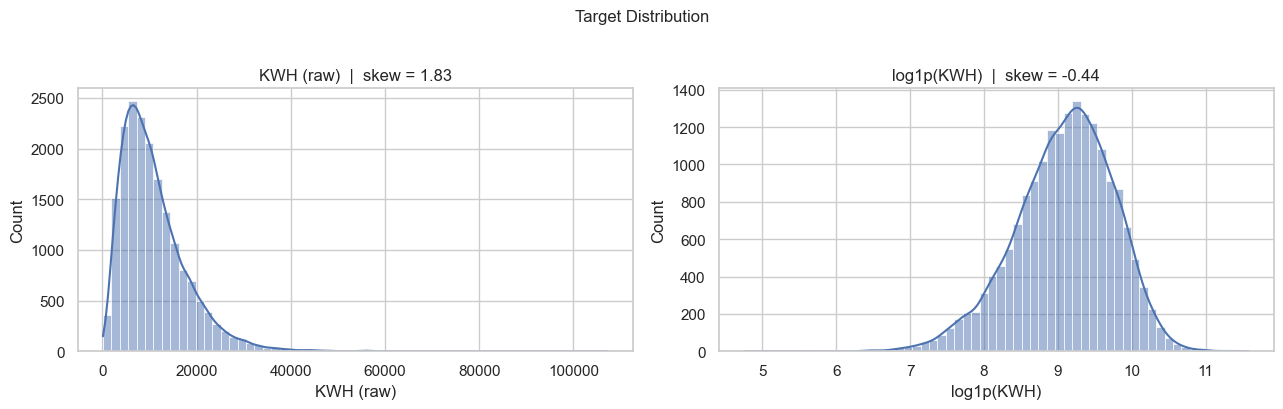

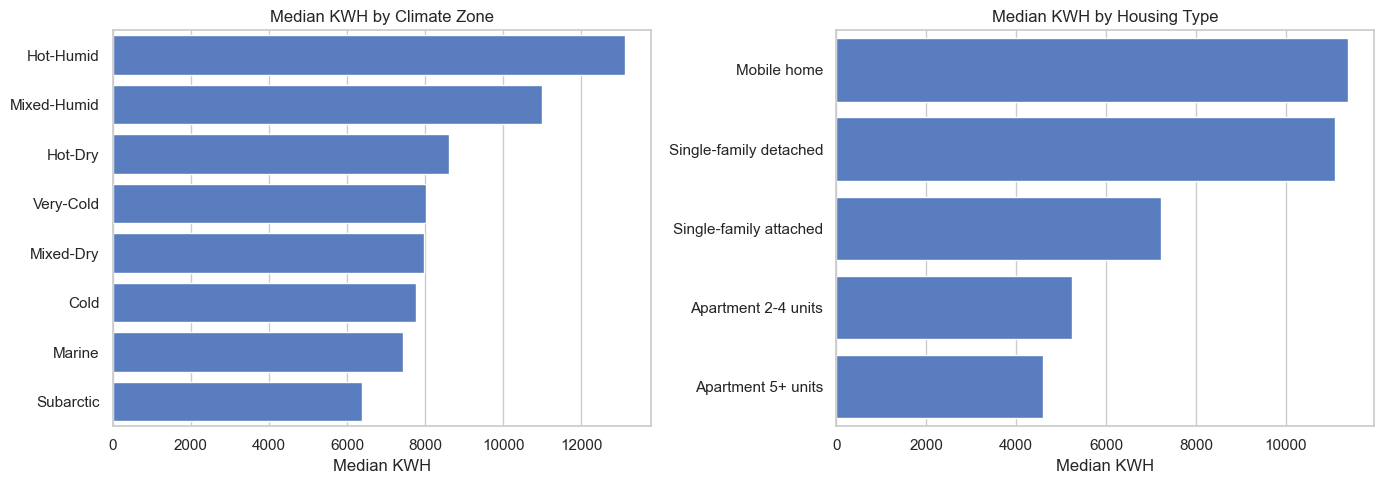

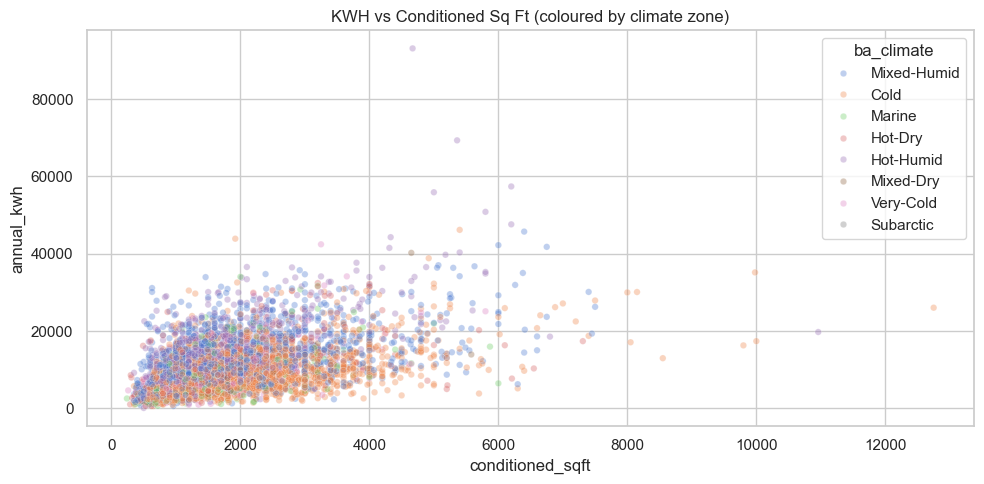

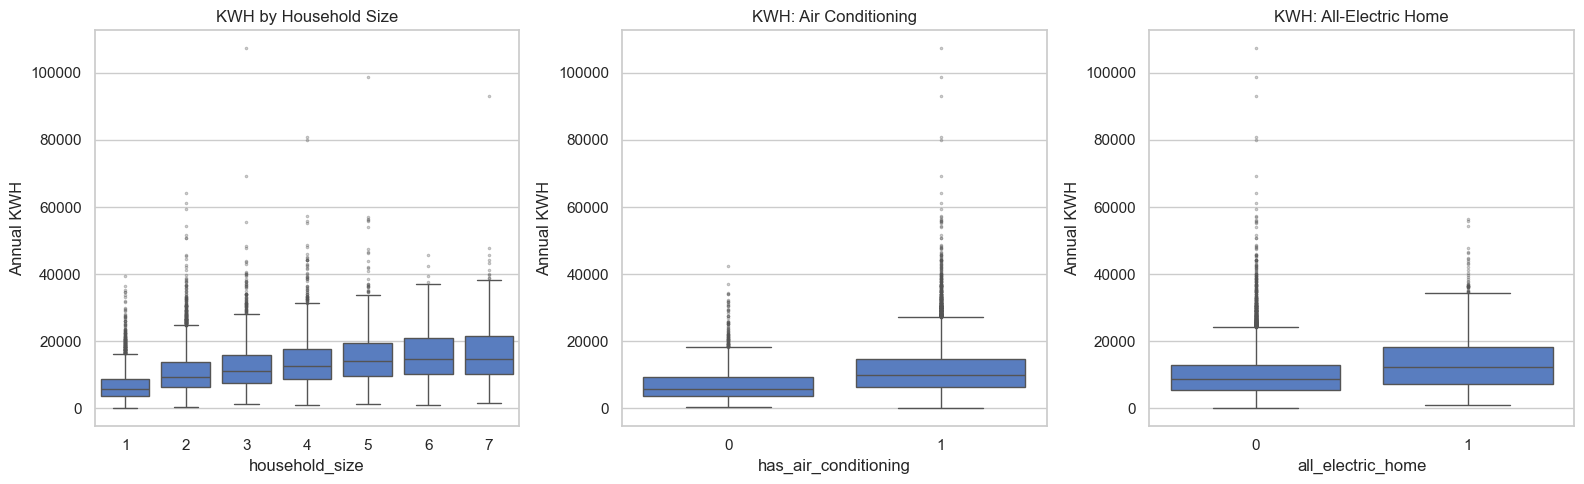

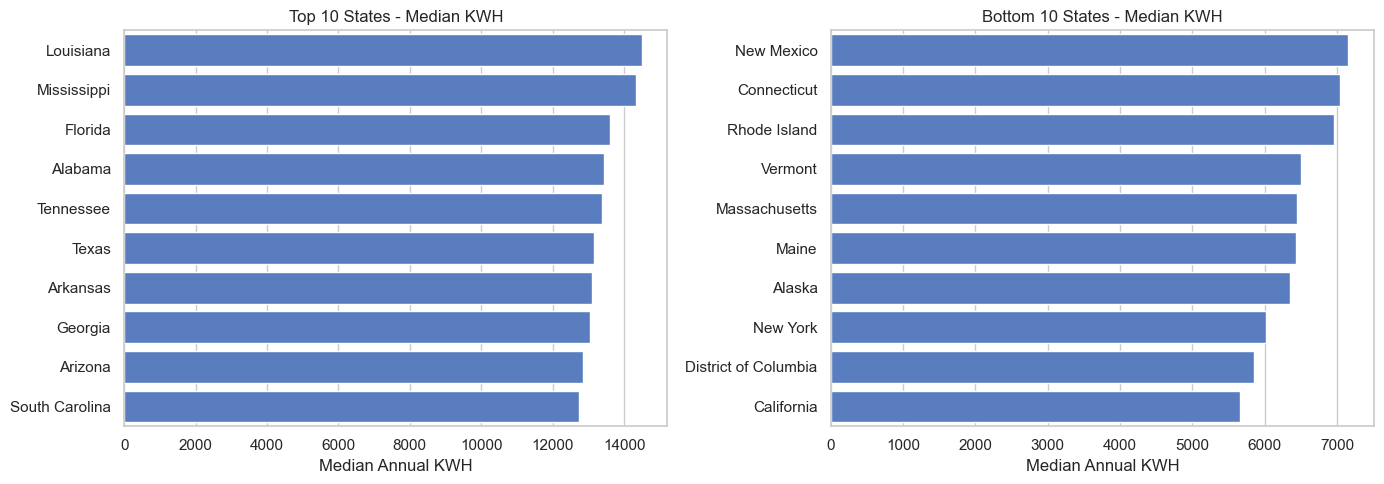

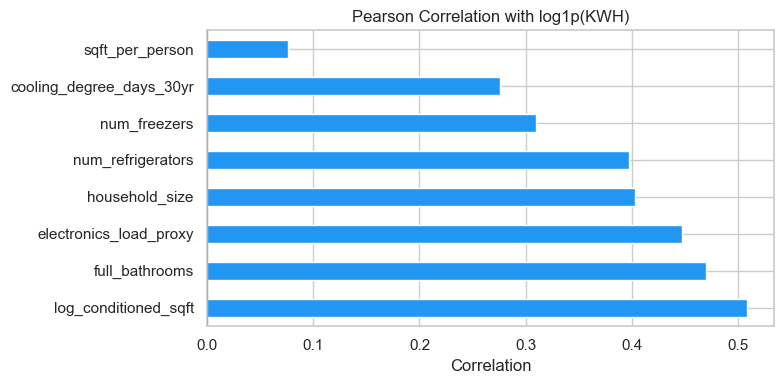

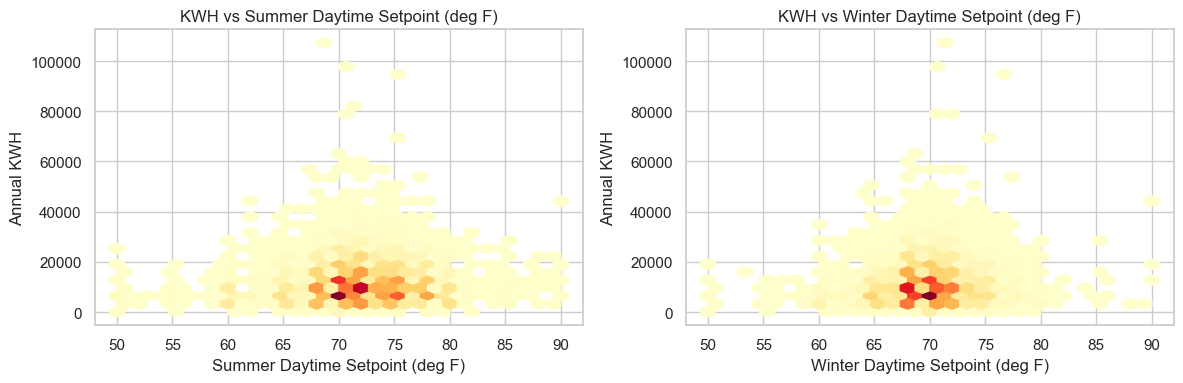

In [17]:
# 5a. Target distribution ------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (vals, label) in zip(axes, [
    (selected_df['annual_kwh'],  'KWH (raw)'),
    (selected_df['log1p_kwh'],   'log1p(KWH)'),
]):
    sns.histplot(vals.dropna(), bins=60, kde=True, ax=ax, color='#4C72B0')
    ax.set_title(f'{label}  |  skew = {vals.skew():.2f}')
    ax.set_xlabel(label)
plt.suptitle('Target Distribution', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(output_dir / 'target_distribution.png', dpi=600, bbox_inches='tight')
plt.show()

# 5b. KWH by climate zone & housing type ---------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (col, title) in zip(axes, [
    ('ba_climate',       'Median KWH by Climate Zone'),
    ('housing_unit_type','Median KWH by Housing Type'),
]):
    plot_data = (selected_df.groupby(col, dropna=False)['annual_kwh']
                 .median().sort_values(ascending=False).reset_index())
    sns.barplot(data=plot_data, x='annual_kwh', y=col, ax=ax)
    ax.set_title(title); ax.set_xlabel('Median KWH'); ax.set_ylabel('')
plt.tight_layout()
plt.savefig(output_dir / 'KWH by climate zone & housing type.png', dpi=600, bbox_inches='tight')
plt.show()

# 5c. KWH vs square footage coloured by climate -------------------------
sample_df = selected_df.sample(min(len(selected_df), 5000), random_state=CONFIG['random_state'])
plt.figure(figsize=(10, 5))
sns.scatterplot(data=sample_df, x='conditioned_sqft', y='annual_kwh',
                hue='ba_climate', alpha=0.35, s=22)
plt.title('KWH vs Conditioned Sq Ft (coloured by climate zone)')
plt.tight_layout()
plt.savefig(output_dir / 'KWH vs square footage coloured by climate.png', dpi=600, bbox_inches='tight')
plt.show()

# 5d. Occupancy & equipment box plots -----------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, title in zip(axes,
    ['household_size', 'has_air_conditioning', 'all_electric_home'],
    ['KWH by Household Size', 'KWH: Air Conditioning', 'KWH: All-Electric Home']):
    sns.boxplot(data=selected_df, x=col, y='annual_kwh', ax=ax,
                flierprops={'marker': '.', 'markersize': 3, 'alpha': 0.4})
    ax.set_title(title); ax.set_xlabel(col); ax.set_ylabel('Annual KWH')
plt.tight_layout()
plt.savefig(output_dir / 'Occupancy & equipment box plots.png', dpi=600, bbox_inches='tight')
plt.show()

# 5e. Geographic variation: top & bottom 10 states ----------------------
state_stats = (selected_df.groupby('state_name', dropna=False)['annual_kwh']
               .agg(median='median', n='count').sort_values('median', ascending=False).reset_index())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, title in zip(axes,
    [state_stats.head(10), state_stats.tail(10)],
    ['Top 10 States - Median KWH', 'Bottom 10 States - Median KWH']):
    sns.barplot(data=df, x='median', y='state_name', ax=ax)
    ax.set_title(title); ax.set_xlabel('Median Annual KWH'); ax.set_ylabel('')
plt.tight_layout()
plt.savefig(output_dir / 'Geographic variation.png', dpi=600, bbox_inches='tight')
plt.show()

# 5f. Correlation with log target ----------------------------------------
num_cols = ['log1p_kwh', 'log_conditioned_sqft', 'full_bathrooms',
            'cooling_degree_days_30yr', 'household_size', 'num_refrigerators',
            'num_freezers', 'sqft_per_person', 'electronics_load_proxy']
corr_target = (selected_df[num_cols].corr()['log1p_kwh']
               .drop('log1p_kwh').sort_values(key=abs, ascending=False))
plt.figure(figsize=(8, 4))
colors = ['#2196F3' if v > 0 else '#F44336' for v in corr_target]
corr_target.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Pearson Correlation with log1p(KWH)')
plt.xlabel('Correlation'); plt.tight_layout()
plt.savefig(output_dir / 'Correlation with log target.png', dpi=600, bbox_inches='tight')
plt.show()

# 5g. Thermostat setpoint vs KWH ----------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, label in zip(axes,
    ['summer_temp_home_day', 'winter_temp_home_day'],
    ['Summer Daytime Setpoint (deg F)', 'Winter Daytime Setpoint (deg F)']):
    valid = selected_df[[col, 'annual_kwh']].dropna()
    ax.hexbin(valid[col], valid['annual_kwh'], gridsize=30, cmap='YlOrRd', mincnt=1)
    ax.set_xlabel(label); ax.set_ylabel('Annual KWH'); ax.set_title(f'KWH vs {label}')
plt.tight_layout()
plt.savefig(output_dir / 'Thermostat setpoint vs KWH.png', dpi=600, bbox_inches='tight')
plt.show()

## 6. Feature Candidate Sets

Three feature sets are used across models:

| Set | Purpose |
|-----|----------|
| **OLS candidate** | Wider starting point for the interpretable OLS specification |
| **Expanded (pruned)** | Compact set after VIF + significance pruning; used across regularised models |
| **Engineered** | Tighter set emphasising derived intensity and behaviour features |

**Leakage exclusions:** `annual_electricity_spend`, `total_site_energy_btu`, `total_energy_spend`, `kwh_per_sqft`, and any KWH/BTU/DOLLAR end-use decomposition fields.

In [7]:
OLS_CANDIDATE_NUMERIC = [
    'log_conditioned_sqft', 'full_bathrooms', 'num_refrigerators', 'num_freezers',
    'household_size', 'num_children', 'householder_age', 'cooling_degree_days_30yr',
]
OLS_CANDIDATE_BINARY = [
    'has_air_conditioning', 'has_dishwasher', 'has_dryer',
    'all_electric_home', 'uses_natural_gas', 'uses_propane',
]
OLS_CANDIDATE_CATEGORICAL = [
    'ba_climate', 'urbanicity_band', 'housing_unit_type', 'tenure', 'employment_band',
]

EXPANDED_NUMERIC = [
    'log_conditioned_sqft', 'full_bathrooms', 'num_refrigerators', 'num_freezers',
    'household_size', 'num_children', 'cooling_degree_days_30yr',
]
EXPANDED_BINARY      = ['has_air_conditioning', 'has_dishwasher', 'has_dryer',
                        'all_electric_home', 'uses_natural_gas']
EXPANDED_CATEGORICAL = ['ba_climate', 'housing_unit_type', 'tenure']

ENGINEERED_NUMERIC = [
    'log_conditioned_sqft', 'full_bathrooms', 'num_refrigerators', 'num_freezers',
    'household_size', 'cooling_degree_days_30yr',
    'sqft_per_person', 'ac_unit_count', 'electronics_load_proxy',
    'children_share', 'summer_setpoint_spread',
]
ENGINEERED_BINARY      = EXPANDED_BINARY.copy()
ENGINEERED_CATEGORICAL = EXPANDED_CATEGORICAL.copy()

print('Feature set sizes:')
for name, n, b, c in [
    ('OLS candidate', OLS_CANDIDATE_NUMERIC, OLS_CANDIDATE_BINARY, OLS_CANDIDATE_CATEGORICAL),
    ('Expanded',      EXPANDED_NUMERIC,      EXPANDED_BINARY,      EXPANDED_CATEGORICAL),
    ('Engineered',    ENGINEERED_NUMERIC,    ENGINEERED_BINARY,    ENGINEERED_CATEGORICAL),
]:
    print(f'  {name:20s}: {len(n)} numeric, {len(b)} binary, {len(c)} categorical')

Feature set sizes:
  OLS candidate       : 8 numeric, 6 binary, 5 categorical
  Expanded            : 7 numeric, 5 binary, 3 categorical
  Engineered          : 11 numeric, 5 binary, 3 categorical


## 7. Train / Test Split & Shared Helpers

Stratified on census region for balanced geographic coverage.

In [8]:
train_idx, test_idx = train_test_split(
    selected_df.index, test_size=CONFIG['test_size'],
    random_state=CONFIG['random_state'],
    stratify=selected_df['census_region'],
)
print(f'Train: {len(train_idx):,}  |  Test: {len(test_idx):,}')

y_train_log = selected_df.loc[train_idx, 'log1p_kwh']
y_test_log  = selected_df.loc[test_idx,  'log1p_kwh']
y_train_raw = selected_df.loc[train_idx, 'annual_kwh']
y_test_raw  = selected_df.loc[test_idx,  'annual_kwh']

# --- Metric helpers -------------------------------------------------------
def adjusted_r2(r2, n, p):
    return np.nan if n <= p + 1 else 1 - (1 - r2) * (n - 1) / (n - p - 1)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mask = y_true != 0
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)

def metric_row(name, scale, y_tr_true, y_tr_pred, y_te_true, y_te_pred, n_feat):
    tr_r2, te_r2 = r2_score(y_tr_true, y_tr_pred), r2_score(y_te_true, y_te_pred)
    return {'model': name, 'scale': scale,
            'train_r2': tr_r2, 'train_adj_r2': adjusted_r2(tr_r2, len(y_tr_true), n_feat),
            'test_r2':  te_r2,  # adj-R2 omitted on test set (not meaningful),
            'train_rmse': rmse(y_tr_true, y_tr_pred), 'test_rmse': rmse(y_te_true, y_te_pred),
            'train_mae': mean_absolute_error(y_tr_true, y_tr_pred),
            'test_mae':  mean_absolute_error(y_te_true, y_te_pred),
            'train_mape': mape(y_tr_true, y_tr_pred),
            'test_mape':  mape(y_te_true, y_te_pred)}

def display_metrics(name, n_feat, pred_tr_log, pred_te_log):
    log_row = metric_row(name, 'log1p(KWH)', y_train_log, pred_tr_log, y_test_log, pred_te_log, n_feat)
    raw_row = metric_row(name, 'KWH', y_train_raw, np.expm1(pred_tr_log),
                         y_test_raw, np.expm1(pred_te_log), n_feat)
    display(pd.DataFrame([log_row, raw_row]).round(4))
    return log_row, raw_row

# --- Preprocessing helpers ------------------------------------------------
def build_preprocessor(numeric_features, binary_features, categorical_features, scale_numeric=True):
    num_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale_numeric:
        num_steps.append(('scaler', StandardScaler()))
    return ColumnTransformer([
        ('num', Pipeline(num_steps), numeric_features),
        ('bin', Pipeline([('imputer', SimpleImputer(strategy='most_frequent'))]), binary_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)),
        ]), categorical_features),
    ], remainder='drop')

def transform_frames(pre, X_tr, X_te):
    X_tr_t = pd.DataFrame(pre.fit_transform(X_tr), columns=pre.get_feature_names_out(), index=X_tr.index)
    X_te_t = pd.DataFrame(pre.transform(X_te),     columns=pre.get_feature_names_out(), index=X_te.index)
    return X_tr_t, X_te_t

# --- Feature importance helpers -------------------------------------------
def collapse_feature_name(feat):
    for pfx in ('num__', 'bin__'):
        if feat.startswith(pfx): return feat[len(pfx):]
    if feat.startswith('cat__'):
        rem = feat[5:]
        for gp in ['ba_climate_', 'state_name_', 'urbanicity_band_', 'housing_unit_type_',
                   'tenure_', 'vintage_band_', 'employment_band_', 'education_band_',
                   'income_band_', 'at_home_band_']:
            if rem.startswith(gp): return gp[:-1]
        return rem
    return feat

def grouped_linear_importance(feature_names, coefficients):
    """Sum |coef| by feature group. NB: coefficients are on the scale
    of the input features (raw for OLS, standardised for regularised
    models), so cross-model comparisons require care."""
    df = pd.DataFrame({'encoded_feature': feature_names, 'coefficient': coefficients})
    df['feature_group'] = df['encoded_feature'].map(collapse_feature_name)
    df['abs_coefficient'] = df['coefficient'].abs()
    grouped = (df.groupby('feature_group', as_index=False)['abs_coefficient']
               .sum().sort_values('abs_coefficient', ascending=False)
               .rename(columns={'abs_coefficient': 'group_importance'}))
    return df.sort_values('abs_coefficient', ascending=False), grouped

# --- Result accumulators --------------------------------------------------
results_target, results_raw = [], []
grouped_imp_tables = {}

# --- fit_and_register: fits any sklearn model and stores results ----------
def fit_and_register(name, model, X_tr, X_te, y_tr=None, y_te=None):
    if y_tr is None: y_tr = y_train_log
    if y_te is None: y_te = y_test_log
    model.fit(X_tr, y_tr)
    pred_tr, pred_te = model.predict(X_tr), model.predict(X_te)
    log_row, raw_row = display_metrics(name, X_tr.shape[1], pred_tr, pred_te)
    results_target.append(log_row); results_raw.append(raw_row)
    if hasattr(model, 'coef_'):
        _, grouped = grouped_linear_importance(X_tr.columns, model.coef_)
        grouped_imp_tables[name] = grouped
    elif hasattr(model, 'feature_importances_'):
        imp_df = pd.DataFrame({'encoded_feature': X_tr.columns,
                               'importance': model.feature_importances_})
        imp_df['feature_group'] = imp_df['encoded_feature'].map(collapse_feature_name)
        grouped_imp_tables[name] = (imp_df.groupby('feature_group', as_index=False)['importance']
                                    .sum().sort_values('importance', ascending=False))
    return model

Train: 14,796  |  Test: 3,700


## 8. Correlation & VIF Review

Screen numeric candidates in domain families. Goal: keep one representative per collinear cluster with VIF < 10.

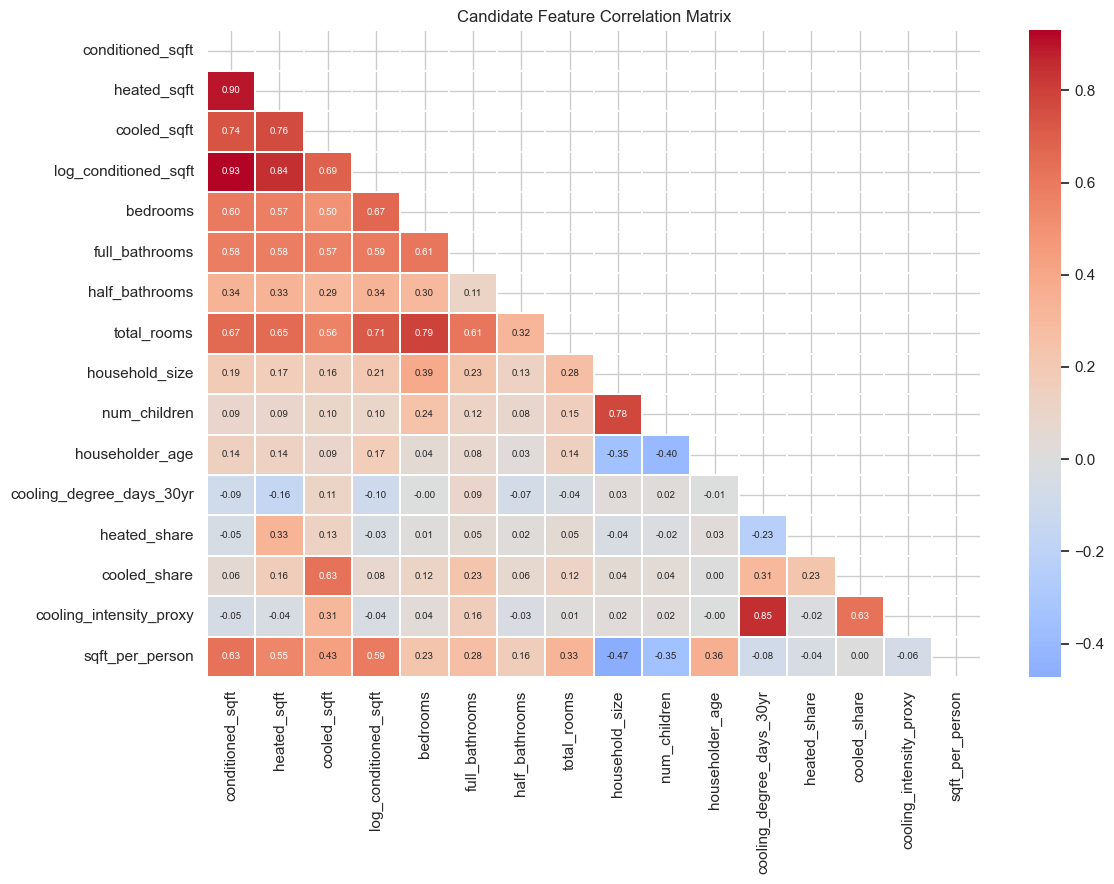

Initial VIF (all candidates):


,feature,vif
0,log_conditioned_sqft,126.800127
1,conditioned_sqft,82.316639
2,heated_sqft,67.160816
3,heated_share,54.263972
4,total_rooms,29.819178
5,cooled_share,27.124674
6,bedrooms,26.229681
7,cooled_sqft,24.824684
8,household_size,22.753023
9,cooling_intensity_proxy,16.272198


Pruned set VIF (target: < 10; mild exceedances for core predictors are acceptable):


,feature,vif
0,log_conditioned_sqft,14.827200
1,household_size,11.918007
2,full_bathrooms,9.042480
3,num_refrigerators,6.460602
4,num_children,3.406943
5,cooling_degree_days_30yr,2.741984
6,num_freezers,1.612318


Pruning decisions:
  Size:       keep log_conditioned_sqft; drop raw area variants (high VIF)
  Layout:     keep full_bathrooms only (bedrooms/total_rooms correlated)
  Occupancy:  keep household_size + num_children (distinct signals)
  Climate:    keep cooling_degree_days_30yr (heating collinear)
  Removed:    heated/cooled shares, cooling_intensity_proxy, sqft_per_person
  Note:       log_conditioned_sqft and household_size remain slightly above 10;
              both are core predictors whose removal would hurt explanatory power
              more than mild collinearity costs inference.


In [9]:
vif_candidates = [
    'conditioned_sqft', 'heated_sqft', 'cooled_sqft', 'log_conditioned_sqft',
    'bedrooms', 'full_bathrooms', 'half_bathrooms', 'total_rooms',
    'household_size', 'num_children', 'householder_age',
    'cooling_degree_days_30yr', 'heated_share', 'cooled_share',
    'cooling_intensity_proxy', 'sqft_per_person',
]
vif_df = selected_df.loc[train_idx, vif_candidates].copy().fillna(
    selected_df.loc[train_idx, vif_candidates].median(numeric_only=True))

# Correlation heatmap (lower triangle)
corr = vif_df.corr()
plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, annot=True,
            fmt='.2f', annot_kws={'size': 7}, linewidths=0.3)
plt.title('Candidate Feature Correlation Matrix')
plt.tight_layout()
plt.savefig(output_dir / 'Correlation heatmap.png', dpi=600, bbox_inches='tight')
plt.show()

def compute_vif(df):
    clean = df.loc[:, df.nunique(dropna=False) > 1].copy()
    clean = clean.fillna(clean.median(numeric_only=True))
    return (pd.DataFrame({'feature': clean.columns,
                           'vif': [variance_inflation_factor(clean.values, i)
                                   for i in range(clean.shape[1])]})
            .sort_values('vif', ascending=False).reset_index(drop=True))

print('Initial VIF (all candidates):')
display(compute_vif(vif_df))

pruned_vif_cols = [
    'log_conditioned_sqft', 'full_bathrooms', 'num_refrigerators', 'num_freezers',
    'household_size', 'num_children', 'cooling_degree_days_30yr',
]
print('Pruned set VIF (target: < 10; mild exceedances for core predictors are acceptable):')
display(compute_vif(selected_df.loc[train_idx, pruned_vif_cols].copy()))

print(
    'Pruning decisions:\n'
    '  Size:       keep log_conditioned_sqft; drop raw area variants (high VIF)\n'
    '  Layout:     keep full_bathrooms only (bedrooms/total_rooms correlated)\n'
    '  Occupancy:  keep household_size + num_children (distinct signals)\n'
    '  Climate:    keep cooling_degree_days_30yr (heating collinear)\n'
    '  Removed:    heated/cooled shares, cooling_intensity_proxy, sqft_per_person\n'
    '  Note:       log_conditioned_sqft and household_size remain slightly above 10;\n'
    '              both are core predictors whose removal would hurt explanatory power\n'
    '              more than mild collinearity costs inference.'
)

## 9. OLS — Baseline Candidate Model

Fit OLS on the wider candidate set, inspect HC3 robust standard errors and significance, then identify features to prune.

In [10]:
ols_pre = build_preprocessor(OLS_CANDIDATE_NUMERIC, OLS_CANDIDATE_BINARY,
                              OLS_CANDIDATE_CATEGORICAL, scale_numeric=False)
X_tr_ols, X_te_ols = transform_frames(
    ols_pre,
    selected_df.loc[train_idx, OLS_CANDIDATE_NUMERIC + OLS_CANDIDATE_BINARY + OLS_CANDIDATE_CATEGORICAL],
    selected_df.loc[test_idx,  OLS_CANDIDATE_NUMERIC + OLS_CANDIDATE_BINARY + OLS_CANDIDATE_CATEGORICAL],
)

initial_ols    = sm.OLS(y_train_log, sm.add_constant(X_tr_ols, has_constant='add')).fit()
initial_ols_hc = initial_ols.get_robustcov_results(cov_type='HC3')
pred_tr_init   = initial_ols.predict(sm.add_constant(X_tr_ols, has_constant='add'))
pred_te_init   = initial_ols.predict(sm.add_constant(X_te_ols, has_constant='add'))

log_row, raw_row = display_metrics('Initial OLS', X_tr_ols.shape[1], pred_tr_init, pred_te_init)
results_target.append(log_row); results_raw.append(raw_row)
_, init_grouped = grouped_linear_importance(X_tr_ols.columns, initial_ols.params.drop('const'))
grouped_imp_tables['Initial OLS'] = init_grouped

print('HC3 robust summary (primary inference view):')
display(initial_ols_hc.summary())

print('Classic OLS summary (supplementary):')
display(initial_ols.summary())

,model,scale,train_r2,train_adj_r2,test_r2,train_rmse,test_rmse,train_mae,test_mae,train_mape,test_mape
0,Initial OLS,log1p(KWH),0.7076,0.7070,0.7025,0.3603,0.3617,0.2741,0.2742,3.0672,3.0705
1,Initial OLS,KWH,0.6013,0.6004,0.5996,4464.5796,4297.7041,2834.3790,2797.1227,30.1011,30.2429


HC3 robust summary (primary inference view):


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log1p_kwh   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.707
Method:                 Least Squares   F-statistic:                     931.6
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:15:54   Log-Likelihood:                -5889.3
No. Observations:               14796   AIC:                         1.184e+04
Df Residuals:                   14763   BIC:                         1.210e+04
Df Model:                          32                                         
Covariance Type:                  HC3                                         
=================================================================================================================
                                                    coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
const                                             5.8259      0.068     85.590      0.000       5.693       5.959
num__log_conditioned_sqft                         0.2402      0.009     27.643      0.000       0.223       0.257
num__full_bathrooms                               0.0818      0.005     15.468      0.000       0.071       0.092
num__num_refrigerators                            0.1283      0.005     23.433      0.000       0.118       0.139
num__num_freezers                                 0.1365      0.005     25.288      0.000       0.126       0.147
num__household_size                               0.1271      0.004     31.059      0.000       0.119       0.135
num__num_children                                -0.0270      0.005     -4.955      0.000      -0.038      -0.016
num__householder_age                             -0.0005      0.000     -2.019      0.043      -0.001   -1.59e-05
num__cooling_degree_days_30yr                     0.0001   6.41e-06     22.799      0.000       0.000       0.000
bin__has_air_conditioning                         0.2869      0.012     23.547      0.000       0.263       0.311
bin__has_dishwasher                               0.0965      0.009     10.690      0.000       0.079       0.114
bin__has_dryer                                    0.2312      0.013     17.438      0.000       0.205       0.257
bin__all_electric_home                            0.2574      0.013     19.234      0.000       0.231       0.284
bin__uses_natural_gas                            -0.2185      0.012    -18.652      0.000      -0.241      -0.196
bin__uses_propane                                -0.0403      0.014     -2.873      0.004      -0.068      -0.013
cat__ba_climate_Hot-Dry                          -0.0835      0.015     -5.482      0.000      -0.113      -0.054
cat__ba_climate_Hot-Humid                         0.0236      0.017      1.404      0.160      -0.009       0.057
cat__ba_climate_Marine                            0.0961      0.016      6.033      0.000       0.065       0.127
cat__ba_climate_Mixed-Dry                        -0.0457      0.045     -1.008      0.313      -0.135       0.043
cat__ba_climate_Mixed-Humid                       0.1783      0.008     21.075      0.000       0.162       0.195
cat__ba_climate_Subarctic                         0.0617      0.064      0.963      0.336      -0.064       0.187
cat__ba_climate_Very-Cold                         0.1363      0.021      6.399      0.000       0.095       0.178
cat__urbanicity_band_R                            0.0271      0.012      2.246      0.025       0.003       0.051
cat__urbanicity_band_U                           -0.0547      0.010     -5.449      0.000      -0.074      -0.035
cat__

Classic OLS summary (supplementary):


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log1p_kwh   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.707
Method:                 Least Squares   F-statistic:                     1116.
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:15:54   Log-Likelihood:                -5889.3
No. Observations:               14796   AIC:                         1.184e+04
Df Residuals:                   14763   BIC:                         1.210e+04
Df Model:                          32                                         
Covariance Type:            nonrobust                                         
=================================================================================================================
                                                    coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
const                                             5.8259      0.064     90.457      0.000       5.700       5.952
num__log_conditioned_sqft                         0.2402      0.008     29.660      0.000       0.224       0.256
num__full_bathrooms                               0.0818      0.005     15.535      0.000       0.071       0.092
num__num_refrigerators                            0.1283      0.005     27.660      0.000       0.119       0.137
num__num_freezers                                 0.1365      0.005     25.834      0.000       0.126       0.147
num__household_size                               0.1271      0.004     34.239      0.000       0.120       0.134
num__num_children                                -0.0270      0.005     -5.146      0.000      -0.037      -0.017
num__householder_age                             -0.0005      0.000     -2.085      0.037      -0.001   -3.24e-05
num__cooling_degree_days_30yr                     0.0001   5.99e-06     24.421      0.000       0.000       0.000
bin__has_air_conditioning                         0.2869      0.010     29.122      0.000       0.268       0.306
bin__has_dishwasher                               0.0965      0.008     11.734      0.000       0.080       0.113
bin__has_dryer                                    0.2312      0.011     20.601      0.000       0.209       0.253
bin__all_electric_home                            0.2574      0.013     19.705      0.000       0.232       0.283
bin__uses_natural_gas                            -0.2185      0.011    -19.027      0.000      -0.241      -0.196
bin__uses_propane                                -0.0403      0.013     -3.000      0.003      -0.067      -0.014
cat__ba_climate_Hot-Dry                          -0.0835      0.015     -5.597      0.000      -0.113      -0.054
cat__ba_climate_Hot-Humid                         0.0236      0.016      1.433      0.152      -0.009       0.056
cat__ba_climate_Marine                            0.0961      0.015      6.482      0.000       0.067       0.125
cat__ba_climate_Mixed-Dry                        -0.0457      0.034     -1.341      0.180      -0.113       0.021
cat__ba_climate_Mixed-Humid                       0.1783      0.009     20.925      0.000       0.162       0.195
cat__ba_climate_Subarctic                         0.0617      0.060      1.023      0.306      -0.057       0.180
cat__ba_climate_Very-Cold                         0.1363      0.018      7.458      0.000       0.100       0.172
cat__urbanicity_band_R                            0.0271      0.012      2.331      0.020       0.004       0.050
cat__urbanicity_band_U                           -0.0547      0.010     -5.490      0.000      -0.074      -0.035
cat__

## 10. OLS — Pruned Model

**Dropped from candidate set:**
- `urbanicity_band`, `employment_band` — weaker incremental contribution than housing type / tenure / climate
- `uses_propane` — niche fuel indicator
- `householder_age` — weaker and less stable than direct occupancy measures

In [11]:
PRUNED_OLS_NUMERIC     = [c for c in OLS_CANDIDATE_NUMERIC if c != 'householder_age']
PRUNED_OLS_BINARY      = [c for c in OLS_CANDIDATE_BINARY  if c != 'uses_propane']
PRUNED_OLS_CATEGORICAL = ['ba_climate', 'housing_unit_type', 'tenure']

pruned_pre = build_preprocessor(PRUNED_OLS_NUMERIC, PRUNED_OLS_BINARY,
                                 PRUNED_OLS_CATEGORICAL, scale_numeric=False)
X_tr_pruned, X_te_pruned = transform_frames(
    pruned_pre,
    selected_df.loc[train_idx, PRUNED_OLS_NUMERIC + PRUNED_OLS_BINARY + PRUNED_OLS_CATEGORICAL],
    selected_df.loc[test_idx,  PRUNED_OLS_NUMERIC + PRUNED_OLS_BINARY + PRUNED_OLS_CATEGORICAL],
)

pruned_ols    = sm.OLS(y_train_log, sm.add_constant(X_tr_pruned, has_constant='add')).fit()
pruned_ols_hc = pruned_ols.get_robustcov_results(cov_type='HC3')
pred_tr_pruned = pruned_ols.predict(sm.add_constant(X_tr_pruned, has_constant='add'))
pred_te_pruned = pruned_ols.predict(sm.add_constant(X_te_pruned, has_constant='add'))

log_row, raw_row = display_metrics('Pruned OLS', X_tr_pruned.shape[1], pred_tr_pruned, pred_te_pruned)
results_target.append(log_row); results_raw.append(raw_row)
_, pruned_grouped = grouped_linear_importance(X_tr_pruned.columns, pruned_ols.params.drop('const'))
grouped_imp_tables['Pruned OLS'] = pruned_grouped

print('HC3 robust summary:')
display(pruned_ols_hc.summary())

,model,scale,train_r2,train_adj_r2,test_r2,train_rmse,test_rmse,train_mae,test_mae,train_mape,test_mape
0,Pruned OLS,log1p(KWH),0.7046,0.7041,0.6988,0.3621,0.3639,0.2756,0.2768,3.0834,3.0991
1,Pruned OLS,KWH,0.5953,0.5946,0.5904,4497.9442,4346.6683,2850.9253,2827.8500,30.2542,30.5309


HC3 robust summary:


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log1p_kwh   R-squared:                       0.705
Model:                            OLS   Adj. R-squared:                  0.704
Method:                 Least Squares   F-statistic:                     1164.
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:15:54   Log-Likelihood:                -5963.5
No. Observations:               14796   AIC:                         1.198e+04
Df Residuals:                   14770   BIC:                         1.218e+04
Df Model:                          25                                         
Covariance Type:                  HC3                                         
=================================================================================================================
                                                    coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
const                                             5.7830      0.067     86.554      0.000       5.652       5.914
num__log_conditioned_sqft                         0.2382      0.009     27.466      0.000       0.221       0.255
num__full_bathrooms                               0.0827      0.005     15.572      0.000       0.072       0.093
num__num_refrigerators                            0.1265      0.006     22.988      0.000       0.116       0.137
num__num_freezers                                 0.1426      0.005     27.086      0.000       0.132       0.153
num__household_size                               0.1293      0.004     32.177      0.000       0.121       0.137
num__num_children                                -0.0215      0.005     -4.001      0.000      -0.032      -0.011
num__cooling_degree_days_30yr                     0.0001   6.43e-06     21.732      0.000       0.000       0.000
bin__has_air_conditioning                         0.2842      0.012     23.213      0.000       0.260       0.308
bin__has_dishwasher                               0.0923      0.009     10.279      0.000       0.075       0.110
bin__has_dryer                                    0.2322      0.013     17.483      0.000       0.206       0.258
bin__all_electric_home                            0.2626      0.011     23.615      0.000       0.241       0.284
bin__uses_natural_gas                            -0.2272      0.009    -26.095      0.000      -0.244      -0.210
cat__ba_climate_Hot-Dry                          -0.0890      0.015     -5.794      0.000      -0.119      -0.059
cat__ba_climate_Hot-Humid                         0.0267      0.017      1.583      0.114      -0.006       0.060
cat__ba_climate_Marine                            0.0833      0.016      5.256      0.000       0.052       0.114
cat__ba_climate_Mixed-Dry                        -0.0496      0.046     -1.088      0.277      -0.139       0.040
cat__ba_climate_Mixed-Humid                       0.1807      0.009     21.243      0.000       0.164       0.197
cat__ba_climate_Subarctic                         0.0651      0.063      1.035      0.301      -0.058       0.188
cat__ba_climate_Very-Cold                         0.1429      0.021      6.702      0.000       0.101       0.185
cat__housing_unit_type_Apartment 5+ units        -0.1423      0.016     -8.625      0.000      -0.175      -0.110
cat__housing_unit_type_Mobile home                0.3992      0.022     18.529      0.000       0.357       0.441
cat__housing_unit_type_Single-family attached     0.0580      0.018      3.189      0.001       0.022       0.094
cat__housing_unit_type_Single-family detached     0.2852      0.017     16.331      0.000       0.251       0.319
cat__

### 10a. Coefficient Plot & Residual Diagnostics

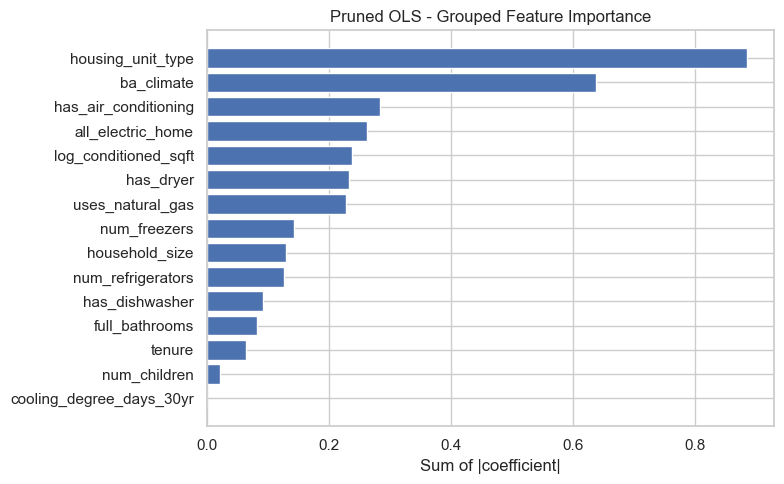

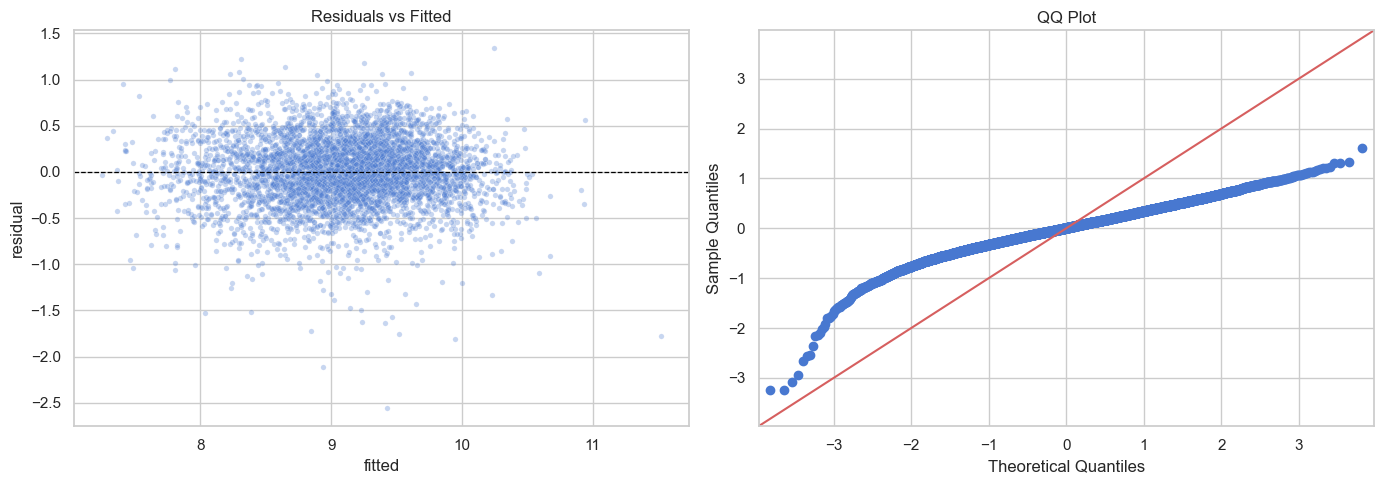

,test,value
0,Jarque-Bera (stat),7.295916e+03
1,Jarque-Bera (p),0.000000e+00
2,KS (stat),2.938830e-02
3,KS (p),1.000000e-03
4,Breusch-Pagan LM,3.090926e+02
5,Breusch-Pagan LM (p),8.967860e-51
6,Breusch-Pagan F,1.260531e+01
7,Breusch-Pagan F (p),2.268169e-51


In [12]:
# Grouped coefficient importance ─ dot plot
imp = pruned_grouped.copy().sort_values('group_importance')
plt.figure(figsize=(8, 5))
plt.barh(imp['feature_group'], imp['group_importance'], color='#4C72B0')
plt.xlabel('Sum of |coefficient|'); plt.title('Pruned OLS - Grouped Feature Importance')
plt.tight_layout()
plt.savefig(output_dir / 'coefficient importance ─ dot plot.png', dpi=600, bbox_inches='tight')
plt.show()

# Residual diagnostics
fitted    = pruned_ols.fittedvalues
residuals = pruned_ols.resid
diag_df   = pd.DataFrame({'fitted': fitted, 'residual': residuals})
plot_df   = (diag_df.sample(CONFIG['diagnostic_plot_sample'], random_state=CONFIG['random_state'])
             if len(diag_df) > CONFIG['diagnostic_plot_sample'] else diag_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=plot_df, x='fitted', y='residual', alpha=0.3, s=15, ax=axes[0])
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.9)
axes[0].set_title('Residuals vs Fitted')
sm.qqplot(residuals, line='45', ax=axes[1])
axes[1].set_title('QQ Plot')
plt.tight_layout()
plt.savefig(output_dir / 'Residual diagnostics.png', dpi=600, bbox_inches='tight')
plt.show()

jb = stats.jarque_bera(residuals)
ks_s, ks_p = kstest_normal(residuals)
bp_lm, bp_lm_p, bp_f, bp_f_p = het_breuschpagan(
    residuals, sm.add_constant(X_tr_pruned, has_constant='add'))

display(pd.DataFrame({
    'test':  ['Jarque-Bera (stat)', 'Jarque-Bera (p)',
              'KS (stat)', 'KS (p)',
              'Breusch-Pagan LM', 'Breusch-Pagan LM (p)',
              'Breusch-Pagan F',  'Breusch-Pagan F (p)'],
    'value': [getattr(jb, 'statistic', jb[0]), getattr(jb, 'pvalue', jb[1]),
              ks_s, ks_p, bp_lm, bp_lm_p, bp_f, bp_f_p],
}))

## 11. Regularised Models & Gradient Boosting

All models use the same expanded feature set for a fair comparison. The `fit_and_register` helper eliminates repetitive boilerplate.

In [13]:
exp_pre = build_preprocessor(EXPANDED_NUMERIC, EXPANDED_BINARY, EXPANDED_CATEGORICAL, scale_numeric=True)
X_tr_exp, X_te_exp = transform_frames(
    exp_pre,
    selected_df.loc[train_idx, EXPANDED_NUMERIC + EXPANDED_BINARY + EXPANDED_CATEGORICAL],
    selected_df.loc[test_idx,  EXPANDED_NUMERIC + EXPANDED_BINARY + EXPANDED_CATEGORICAL],
)

# Naive baseline
log_row, raw_row = display_metrics('Naive mean baseline', 0,
    np.repeat(y_train_log.mean(), len(y_train_log)),
    np.repeat(y_train_log.mean(), len(y_test_log)))
results_target.append(log_row); results_raw.append(raw_row)

# Main model suite
linear = fit_and_register('Linear regression', LinearRegression(), X_tr_exp, X_te_exp)
ridge  = fit_and_register('Ridge', RidgeCV(alphas=np.logspace(-3, 3, 25)), X_tr_exp, X_te_exp)
lasso  = fit_and_register('Lasso',
    LassoCV(cv=5, random_state=CONFIG['random_state'], max_iter=20_000), X_tr_exp, X_te_exp)
enet   = fit_and_register('Elastic Net',
    ElasticNetCV(l1_ratio=[.1,.3,.5,.7,.9,1.], cv=5,
                 random_state=CONFIG['random_state'], max_iter=20_000), X_tr_exp, X_te_exp)

if CONFIG['run_hist_gradient_boosting']:
    hgb = fit_and_register('HistGradientBoosting',
        HistGradientBoostingRegressor(max_depth=6, learning_rate=0.05,
                                      max_iter=400, random_state=CONFIG['random_state']),
        X_tr_exp, X_te_exp)

# PCA + Linear
pca_full_pre = ColumnTransformer([
    ('num_pca', Pipeline([('imp', SimpleImputer(strategy='median')),
                          ('scaler', StandardScaler()), ('pca', PCA(n_components=0.95))]),
     EXPANDED_NUMERIC),
    ('bin', Pipeline([('imp', SimpleImputer(strategy='most_frequent'))]), EXPANDED_BINARY),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore',
                                            sparse_output=False))]), EXPANDED_CATEGORICAL),
])
X_tr_pca = pca_full_pre.fit_transform(
    selected_df.loc[train_idx, EXPANDED_NUMERIC + EXPANDED_BINARY + EXPANDED_CATEGORICAL])
X_te_pca = pca_full_pre.transform(
    selected_df.loc[test_idx,  EXPANDED_NUMERIC + EXPANDED_BINARY + EXPANDED_CATEGORICAL])
pca_lr = LinearRegression().fit(X_tr_pca, y_train_log)
log_row, raw_row = display_metrics('PCA + Linear', X_tr_pca.shape[1],
    pca_lr.predict(X_tr_pca), pca_lr.predict(X_te_pca))
results_target.append(log_row); results_raw.append(raw_row)

,model,scale,train_r2,train_adj_r2,test_r2,train_rmse,test_rmse,train_mae,test_mae,train_mape,test_mape
0,Naive mean baseline,log1p(KWH),0.0000,0.0000,-0.0006,0.6662,0.6633,0.5278,0.5299,5.9407,5.9761
1,Naive mean baseline,KWH,-0.0801,-0.0801,-0.0707,7348.1802,7027.7638,5150.8530,5073.9877,66.3348,66.2769


,model,scale,train_r2,train_adj_r2,test_r2,train_rmse,test_rmse,train_mae,test_mae,train_mape,test_mape
0,Linear regression,log1p(KWH),0.7046,0.7041,0.6988,0.3621,0.3639,0.2756,0.2768,3.0834,3.0991
1,Linear regression,KWH,0.5953,0.5946,0.5904,4497.9442,4346.6683,2850.9253,2827.8500,30.2542,30.5309


,model,scale,train_r2,train_adj_r2,test_r2,train_rmse,test_rmse,train_mae,test_mae,train_mape,test_mape
0,Ridge,log1p(KWH),0.7046,0.7041,0.6988,0.3621,0.3639,0.2756,0.2768,3.0838,3.0991
1,Ridge,KWH,0.5955,0.5948,0.5906,4497.0980,4345.8051,2850.7574,2826.9601,30.2601,30.5294


,model,scale,train_r2,train_adj_r2,test_r2,train_rmse,test_rmse,train_mae,test_mae,train_mape,test_mape
0,Lasso,log1p(KWH),0.7045,0.7040,0.6985,0.3622,0.3641,0.2756,0.2769,3.0842,3.1007
1,Lasso,KWH,0.5962,0.5955,0.5907,4493.1772,4345.1881,2849.7564,2826.8440,30.2720,30.5437


,model,scale,train_r2,train_adj_r2,test_r2,train_rmse,test_rmse,train_mae,test_mae,train_mape,test_mape
0,Elastic Net,log1p(KWH),0.7045,0.7040,0.6985,0.3622,0.3641,0.2756,0.2769,3.0842,3.1007
1,Elastic Net,KWH,0.5962,0.5955,0.5907,4493.1772,4345.1881,2849.7564,2826.8440,30.2720,30.5437


,model,scale,train_r2,train_adj_r2,test_r2,train_rmse,test_rmse,train_mae,test_mae,train_mape,test_mape
0,HistGradientBoosting,log1p(KWH),0.7827,0.7823,0.7611,0.3106,0.3241,0.2344,0.2460,2.6247,2.7558
1,HistGradientBoosting,KWH,0.7345,0.7340,0.7144,3643.3240,3629.6920,2390.3796,2463.5049,25.1643,26.6415


,model,scale,train_r2,train_adj_r2,test_r2,train_rmse,test_rmse,train_mae,test_mae,train_mape,test_mape
0,PCA + Linear,log1p(KWH),0.6978,0.6973,0.6906,0.3662,0.3688,0.2800,0.2804,3.1339,3.1411
1,PCA + Linear,KWH,0.5947,0.5941,0.5760,4501.2985,4422.3829,2883.6849,2852.9689,30.7327,31.0341


## 12. Engineered-Feature Extension

Rerun main models on the engineered set (sqft_per_person, ac_unit_count, electronics_load_proxy, children_share, summer_setpoint_spread) to check whether tighter derived features change results.

In [14]:
eng_pre = build_preprocessor(ENGINEERED_NUMERIC, ENGINEERED_BINARY,
                              ENGINEERED_CATEGORICAL, scale_numeric=True)
X_tr_eng, X_te_eng = transform_frames(
    eng_pre,
    selected_df.loc[train_idx, ENGINEERED_NUMERIC + ENGINEERED_BINARY + ENGINEERED_CATEGORICAL],
    selected_df.loc[test_idx,  ENGINEERED_NUMERIC + ENGINEERED_BINARY + ENGINEERED_CATEGORICAL],
)

for name, model in [
    ('Engineered Linear',      LinearRegression()),
    ('Engineered Ridge',       RidgeCV(alphas=np.logspace(-3, 3, 25))),
    ('Engineered Lasso',       LassoCV(cv=5, random_state=CONFIG['random_state'], max_iter=20_000)),
    ('Engineered Elastic Net', ElasticNetCV(l1_ratio=[.1,.3,.5,.7,.9,1.], cv=5,
                                             random_state=CONFIG['random_state'], max_iter=20_000)),
]:
    fit_and_register(name, model, X_tr_eng, X_te_eng)

if CONFIG['run_hist_gradient_boosting']:
    fit_and_register('Engineered HGB',
        HistGradientBoostingRegressor(max_depth=6, learning_rate=0.05,
                                      max_iter=400, random_state=CONFIG['random_state']),
        X_tr_eng, X_te_eng)

,model,scale,train_r2,train_adj_r2,test_r2,train_rmse,test_rmse,train_mae,test_mae,train_mape,test_mape
0,Engineered Linear,log1p(KWH),0.7148,0.7143,0.7095,0.3558,0.3574,0.2702,0.2717,3.0240,3.040
1,Engineered Linear,KWH,0.6053,0.6045,0.5987,4442.1691,4302.4218,2797.6384,2783.1382,29.5707,29.712


,model,scale,train_r2,train_adj_r2,test_r2,train_rmse,test_rmse,train_mae,test_mae,train_mape,test_mape
0,Engineered Ridge,log1p(KWH),0.7148,0.7143,0.7095,0.3558,0.3574,0.2702,0.2717,3.0240,3.0404
1,Engineered Ridge,KWH,0.6054,0.6047,0.5989,4441.4060,4301.6613,2797.1166,2782.4210,29.5735,29.7137


,model,scale,train_r2,train_adj_r2,test_r2,train_rmse,test_rmse,train_mae,test_mae,train_mape,test_mape
0,Engineered Lasso,log1p(KWH),0.7147,0.7141,0.7092,0.3559,0.3576,0.2703,0.2719,3.0244,3.0424
1,Engineered Lasso,KWH,0.6062,0.6054,0.5990,4437.2136,4301.0239,2795.9132,2782.5087,29.5854,29.7287


,model,scale,train_r2,train_adj_r2,test_r2,train_rmse,test_rmse,train_mae,test_mae,train_mape,test_mape
0,Engineered Elastic Net,log1p(KWH),0.7147,0.7141,0.7092,0.3559,0.3576,0.2703,0.2719,3.0244,3.0424
1,Engineered Elastic Net,KWH,0.6062,0.6054,0.5990,4437.2136,4301.0239,2795.9132,2782.5087,29.5854,29.7287


,model,scale,train_r2,train_adj_r2,test_r2,train_rmse,test_rmse,train_mae,test_mae,train_mape,test_mape
0,Engineered HGB,log1p(KWH),0.8034,0.8030,0.7709,0.2954,0.3174,0.2229,0.2395,2.4951,2.6809
1,Engineered HGB,KWH,0.7664,0.7659,0.7194,3417.6655,3597.4908,2265.2891,2401.7122,23.6967,25.7379


## 13. Model Comparison & Conclusion

In [15]:
res_log = pd.DataFrame(results_target).sort_values('test_r2', ascending=False).reset_index(drop=True)
res_raw = pd.DataFrame(results_raw).sort_values('test_r2',  ascending=False).reset_index(drop=True)

print('Model comparison -- log1p(KWH) scale')
display(res_log.round(4))
print('\nModel comparison -- KWH scale (business view)')
display(res_raw.round(4))

Model comparison -- log1p(KWH) scale


,model,scale,train_r2,train_adj_r2,test_r2,train_rmse,test_rmse,train_mae,test_mae,train_mape,test_mape
0,Engineered HGB,log1p(KWH),0.8034,0.8030,0.7709,0.2954,0.3174,0.2229,0.2395,2.4951,2.6809
1,HistGradientBoosting,log1p(KWH),0.7827,0.7823,0.7611,0.3106,0.3241,0.2344,0.2460,2.6247,2.7558
2,Engineered Linear,log1p(KWH),0.7148,0.7143,0.7095,0.3558,0.3574,0.2702,0.2717,3.0240,3.0400
3,Engineered Ridge,log1p(KWH),0.7148,0.7143,0.7095,0.3558,0.3574,0.2702,0.2717,3.0240,3.0404
4,Engineered Elastic Net,log1p(KWH),0.7147,0.7141,0.7092,0.3559,0.3576,0.2703,0.2719,3.0244,3.0424
5,Engineered Lasso,log1p(KWH),0.7147,0.7141,0.7092,0.3559,0.3576,0.2703,0.2719,3.0244,3.0424
6,Initial OLS,log1p(KWH),0.7076,0.7070,0.7025,0.3603,0.3617,0.2741,0.2742,3.0672,3.0705
7,Ridge,log1p(KWH),0.7046,0.7041,0.6988,0.3621,0.3639,0.2756,0.2768,3.0838,3.0991
8,Linear regression,log1p(KWH),0.7046,0.7041,0.6988,0.3621,0.3639,0.2756,0.2768,3.0834,3.0991
9,Pruned OLS,log1p(KWH),0.7046,0.7041,0.6988,0.3621,0.3639,0.2756,0.2768,3.0834,3.0991



Model comparison -- KWH scale (business view)


,model,scale,train_r2,train_adj_r2,test_r2,train_rmse,test_rmse,train_mae,test_mae,train_mape,test_mape
0,Engineered HGB,KWH,0.7664,0.7659,0.7194,3417.6655,3597.4908,2265.2891,2401.7122,23.6967,25.7379
1,HistGradientBoosting,KWH,0.7345,0.7340,0.7144,3643.3240,3629.6920,2390.3796,2463.5049,25.1643,26.6415
2,Initial OLS,KWH,0.6013,0.6004,0.5996,4464.5796,4297.7041,2834.3790,2797.1227,30.1011,30.2429
3,Engineered Lasso,KWH,0.6062,0.6054,0.5990,4437.2136,4301.0239,2795.9132,2782.5087,29.5854,29.7287
4,Engineered Elastic Net,KWH,0.6062,0.6054,0.5990,4437.2136,4301.0239,2795.9132,2782.5087,29.5854,29.7287
5,Engineered Ridge,KWH,0.6054,0.6047,0.5989,4441.4060,4301.6613,2797.1166,2782.4210,29.5735,29.7137
6,Engineered Linear,KWH,0.6053,0.6045,0.5987,4442.1691,4302.4218,2797.6384,2783.1382,29.5707,29.7120
7,Lasso,KWH,0.5962,0.5955,0.5907,4493.1772,4345.1881,2849.7564,2826.8440,30.2720,30.5437
8,Elastic Net,KWH,0.5962,0.5955,0.5907,4493.1772,4345.1881,2849.7564,2826.8440,30.2720,30.5437
9,Ridge,KWH,0.5955,0.5948,0.5906,4497.0980,4345.8051,2850.7574,2826.9601,30.2601,30.5294


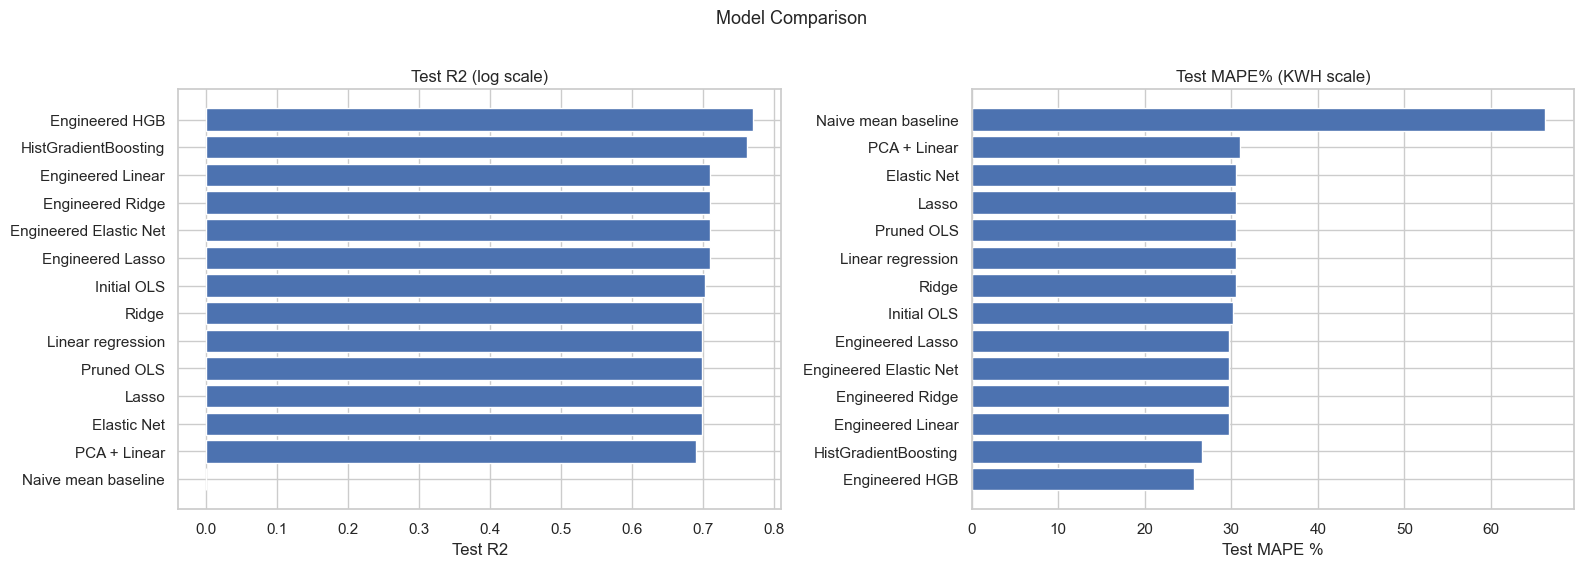

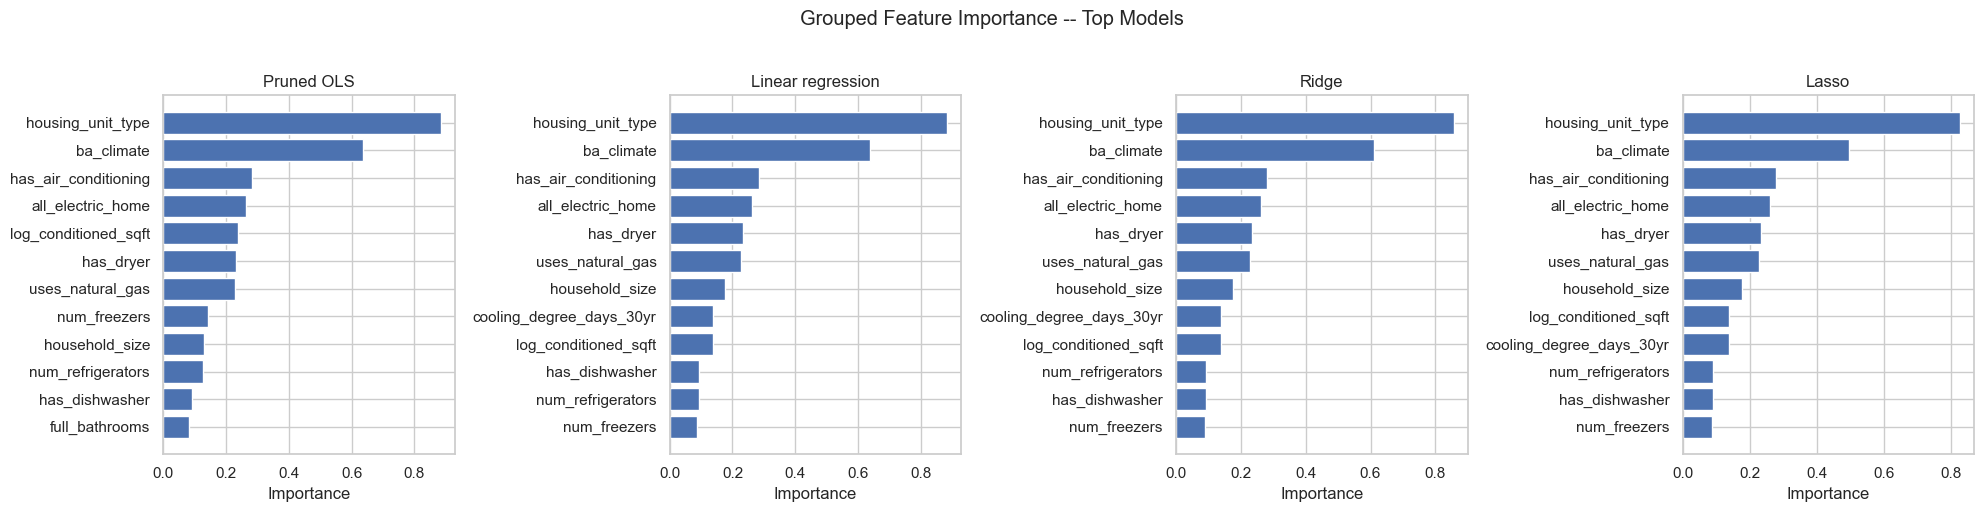

In [16]:
# Visual comparison: test R2 and test MAPE
fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(res_log) * 0.4)))
for ax, df, col, xlabel, title in [
    (axes[0], res_log.sort_values('test_r2'),   'test_r2',   'Test R2',    'Test R2 (log scale)'),
    (axes[1], res_raw.sort_values('test_mape'),  'test_mape', 'Test MAPE %','Test MAPE% (KWH scale)'),
]:
    ax.barh(df['model'], df[col], color='#4C72B0')
    ax.set_xlabel(xlabel); ax.set_title(title)
plt.suptitle('Model Comparison', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(output_dir / 'test R2 and test MAPE.png', dpi=600, bbox_inches='tight')
plt.show()

# Grouped importance: top models
top_models = ['Pruned OLS', 'Linear regression', 'Ridge', 'Lasso', 'HistGradientBoosting']
avail = [k for k in top_models if k in grouped_imp_tables]
if avail:
    fig, axes = plt.subplots(1, len(avail), figsize=(5 * len(avail), 5), sharey=False)
    if len(avail) == 1: axes = [axes]
    for ax, name in zip(axes, avail):
        tbl = grouped_imp_tables[name].head(12)
        val_col = [c for c in tbl.columns if c != 'feature_group'][0]
        tbl_sorted = tbl.sort_values(val_col)
        ax.barh(tbl_sorted['feature_group'], tbl_sorted[val_col], color='#4C72B0')
        ax.set_title(name); ax.set_xlabel('Importance')
    plt.suptitle('Grouped Feature Importance -- Top Models', y=1.02)
    plt.tight_layout()
    plt.savefig(output_dir / 'Grouped importance.png', dpi=600, bbox_inches='tight')
    plt.show()

## Conclusion

This workflow separates three concerns:

1. **Interpretability** — The pruned OLS model (test R² ≈ 0.70 log-scale, 0.59 KWH-scale) with HC3 robust SEs identifies the main drivers: housing type, climate zone, air conditioning status, all-electric status, dwelling size (`log_conditioned_sqft`), and dryer ownership carry the largest grouped coefficients.

2. **Predictive performance** — Regularised linear models (Ridge, Lasso, Elastic Net) match OLS closely, confirming the specification is near-efficient for linear methods. HistGradientBoosting delivers a meaningful lift (test R² 0.76–0.77 log-scale, 0.71–0.72 KWH-scale), suggesting nonlinearities and interactions that linear models miss.

3. **Feature engineering** — The engineered feature set lifts linear models by ~1 pp in test R² and gives HGB its best result (0.77 log-scale), validating that composite features like `electronics_load_proxy` and `sqft_per_person` add real signal beyond the raw inputs.

**Reading the OLS summary:**
- `coef` is the change in log1p(KWH) per unit; for small values this approximates a % change.
- HC3 robust SEs are the primary inference view; classic SEs are supplementary.
- The omitted dummy level is the reference category for each categorical block.